# 4주차 실습 (1) — Singular Value Decomposition (SVD)

> PCA는 “데이터가 가장 많이 퍼진 방향”을 찾는 것이고, 그 방향을 찾는 계산 도구로 고유분해나 SVD를 쓸 수 있다.

> **SVD는 선형대수의 맥가이버칼이다. 모든 행렬은 SVD를 가지고, 모든 데이터 과학자에겐 SVD가 필요하다.**

- **Type:** Build · **Languages:** Python, Julia · **Time:** ~120분
- **선수 지식:** Phase 1 Lesson 01(선형대수 직관), 02(벡터·행렬 연산), 03(행렬 변환)
- 원문: <https://aiengineeringfromscratch.com/lesson.html?path=phases/01-math-foundations/11-singular-value-decomposition>

## 🎯 학습 목표 (Learning Objectives)

1. **거듭제곱 반복(power iteration)** 으로 SVD를 밑바닥부터 구현하고, `U`, `Σ`, `Vᵀ`의 **기하학적 의미**를 설명한다.
2. **잘린 SVD(truncated SVD)** 를 이미지 압축에 적용하고 **압축률 vs 복원 오차**를 측정한다.
3. **무어-펜로즈 유사역행렬**을 SVD로 계산해 **과결정 최소제곱 문제**를 푼다.
4. SVD를 **PCA / 추천 시스템(잠재 요인) / NLP의 LSA**와 연결한다.

---

## 📖 이 노트북을 읽는 법

각 주제마다 이 순서로 반복된다:

> 🧸 **비유** (초등학생용) → 📐 **개념** (정확한 정의) → 💻 **코드** (직접 증명) → 🏭 **실무** (어디에 쓰나)

| # | 주제 |
| --- | --- |
| 0 | 문제 상황 — 왜 고유분해로는 부족한가 |
| 1 | 비유와 정의 — 돌리고·늘리고·돌리기 |
| 2 | 세 조각의 의미 (`U`, `Σ`, `V`) 와 `A vᵢ = σᵢ uᵢ` |
| 3 | 외적(rank-1) 합 형태 — 레이어로 쌓기 |
| 4 | 잘린 SVD와 Eckart–Young 정리 |
| 5 | 고유분해와의 관계 & 수치 안정성 |
| 6 | 🏭 실무 1 — 이미지 압축 |
| 7 | 🏭 실무 2 — 노이즈 제거 |
| 8 | 🏭 실무 3 — 추천 시스템(잠재 요인) |
| 9 | 🏭 실무 4 — NLP의 잠재 의미 분석(LSA) |
| 10 | 🏭 실무 5 — 유사역행렬과 최소제곱 |
| 11 | 🏭 실무 6 — PCA는 사실 SVD다 |
| 12 | 🔨 Build It — 밑바닥부터 구현 (power iteration) |
| 13 | 📝 연습문제 5개 (풀이 포함) |
| 14 | 📚 용어 사전 · Ship It · 더 읽을거리 |

## 0️⃣ 문제 상황 (The Problem)

1000×2000 행렬이 하나 있다고 하자.
- 사용자-영화 **평점표**일 수도 있고,
- 문서-단어 **빈도표**일 수도 있고,
- 이미지의 **픽셀 값**일 수도 있다.

여기서 하고 싶은 일: **압축**하거나, **노이즈를 빼거나**, **숨은 구조를 찾거나**, **최소제곱 문제를 풀거나**.

그런데 우리가 아는 **고유분해(eigendecomposition)** 는 조건이 까다롭다.

- ❌ **정사각행렬**에만 쓸 수 있다. (1000×2000은 아예 불가)
- ❌ 정사각이어도 **일차독립인 고유벡터가 꽉 차 있어야** 한다. (아니면 대각화 불가)

> **SVD는 조건이 없다.** 어떤 모양이든, 어떤 계수(rank)든, 언제나 존재한다.
> 그리고 그 행렬이 **공간에 무슨 짓을 하는지** 기하학적으로 낱낱이 드러낸다.
> 선형대수 전체에서 **가장 일반적이고 가장 쓸모 있는 분해**다.

In [5]:
# ── 공통 설정 (그림의 한글 폰트 포함) ──────────────────────────────
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=4, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        # 한글 폰트 + DejaVu 폴백(한글 폰트에 없는 ᵀ, ᵢ 같은 기호용)
        matplotlib.rcParams["font.family"] = [cand, "DejaVu Sans"]
        break
matplotlib.rcParams["axes.unicode_minus"] = False       # 한글 폰트에서 마이너스 깨짐 방지
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"  # 수식(σ, 지수)은 DejaVu로

import matplotlib.ticker as mticker
def plain_log(ax):
    # 로그축 눈금을 한글 폰트에서도 깨지지 않는 일반 텍스트로 바꾼다
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

matplotlib.rcParams["figure.dpi"] = 110
print("그림 폰트:", matplotlib.rcParams["font.family"])

그림 폰트: ['Apple SD Gothic Neo', 'DejaVu Sans']


In [6]:
# (1) 정사각이 아닌 행렬 -> 고유분해 자체가 불가능
A_rect = np.random.default_rng(0).standard_normal((5, 3))
try:
    np.linalg.eig(A_rect)
except np.linalg.LinAlgError as e:
    print("직사각 행렬 고유분해:", type(e).__name__, "-", e)

# (2) 정사각이지만 '결손(defective)' 행렬 -> 고유벡터가 부족해 대각화 불가
A_def = np.array([[1.0, 1.0],
                  [0.0, 1.0]])          # 고유값 1이 두 번이지만 고유벡터는 1개뿐
vals, vecs = np.linalg.eig(A_def)
print("\n결손 행렬 고유값:", vals)
print("고유벡터 행렬의 rank:", np.linalg.matrix_rank(vecs), "(2가 아니면 대각화 불가)")

# (3) SVD는 둘 다 아무 문제 없이 된다
for name, M in [("직사각 5x3", A_rect), ("결손 2x2", A_def)]:
    U, S, Vt = np.linalg.svd(M)
    print(f"\nSVD OK - {name}: U{U.shape}  S{S.shape}  Vt{Vt.shape}  특이값={np.round(S,4)}")

직사각 행렬 고유분해: LinAlgError - Last 2 dimensions of the array must be square

결손 행렬 고유값: [1. 1.]
고유벡터 행렬의 rank: 1 (2가 아니면 대각화 불가)

SVD OK - 직사각 5x3: U(5, 5)  S(3,)  Vt(3, 3)  특이값=[3.1509 1.7093 0.3349]

SVD OK - 결손 2x2: U(2, 2)  S(2,)  Vt(2, 2)  특이값=[1.618 0.618]


## 1️⃣ 🧸 비유 — "모든 행렬은 돌리고 → 늘리고 → 돌린다"

**찰흙으로 만든 동그란 구슬**을 상상하자. 이 구슬을 손으로 주물러서 **길쭉한 럭비공**으로 만든다.

아무리 복잡하게 주물러도, 그 동작은 항상 **딱 세 단계**로 쪼갤 수 있다.

```
1) 구슬을 빙글 돌린다        ← Vᵀ (회전)
2) 각 축 방향으로 쭉 늘린다   ← Σ  (크기 조절, 축마다 다른 배율)
3) 럭비공을 다시 빙글 돌린다  ← U  (회전)
```

- 늘이는 단계에서 **"몇 배 늘렸나"** 가 바로 **특이값(singular value) σ**다.
- 럭비공의 **가장 긴 반지름 = σ₁**, 두 번째로 긴 반지름 = σ₂ …
- 어느 방향으로 **0배** 늘렸다면(σ=0), 그 방향은 **납작하게 짜부라진 것** — 정보가 사라진 방향이다.

> 🧠 한 줄: **SVD는 "이 행렬이 공을 어느 방향으로 얼마나 늘렸는지"를 알려주는 설명서다.**

### 📐 개념 — 정식 정의

모든 `m × n` 행렬 `A`에 대해 다음 분해가 **항상** 존재한다.

```
A  =  U   ·   Σ   ·   Vᵀ

  m x n    m x m    m x n    n x n
  (임의)   (회전)   (크기)   (회전)
```

- `U` : `m × m` **직교행렬** (`UᵀU = I`) — 열들을 **왼쪽 특이벡터(left singular vector)** 라 부른다
- `Σ` : `m × n` **대각행렬** — 대각에 **특이값**이 들어간다
- `V` : `n × n` **직교행렬** (`VᵀV = I`) — 열들을 **오른쪽 특이벡터(right singular vector)** 라 부른다

특이값은 **항상 0 이상**이고, 관례적으로 **내림차순**으로 정렬한다.

```
σ₁ ≥ σ₂ ≥ … ≥ σ_r > 0       (r = rank(A))
```

> ⚠️ `np.linalg.svd`는 `U, S, Vt`를 돌려준다. 세 번째가 **`V`가 아니라 `Vᵀ`** 라는 점을 늘 조심할 것.
> `full_matrices=False`를 주면 `U`가 `m×k`, `Vt`가 `k×n` (`k=min(m,n)`)인 **경제형(thin) SVD**가 나온다.

In [7]:
rng = np.random.default_rng(42)
A = rng.standard_normal((5, 4))

# full SVD: U(5x5), Vt(4x4), S는 길이 4짜리 '벡터'로 나온다(대각 성분만)
U, S, Vt = np.linalg.svd(A)
print("full  :", U.shape, S.shape, Vt.shape)

# thin(경제형) SVD: 계산/메모리 절약. 실무에서 대부분 이걸 쓴다
Ue, Se, Vte = np.linalg.svd(A, full_matrices=False)
print("thin  :", Ue.shape, Se.shape, Vte.shape)

print("\n특이값 σ =", np.round(S, 4), " -> 내림차순 정렬:", np.all(np.diff(S) <= 0))
print("모두 0 이상:", np.all(S >= 0))
print("rank(A) =", np.linalg.matrix_rank(A), " == 0이 아닌 특이값 개수:", np.sum(S > 1e-10))

# 직교성 검증: UᵀU = I,  VᵀV = I
print("\n‖UᵀU - I‖ =", np.linalg.norm(U.T @ U - np.eye(5)))
print("‖VᵀV - I‖ =", np.linalg.norm(Vt @ Vt.T - np.eye(4)))

# 복원 검증: A = U Σ Vᵀ  (thin 버전으로)
A_rec = Ue @ np.diag(Se) @ Vte
print("\n복원 오차 ‖A - UΣVᵀ‖ =", np.linalg.norm(A - A_rec))

full  : (5, 5) (4,) (4, 4)
thin  : (5, 4) (4,) (4, 4)

특이값 σ = [2.8376 2.1359 1.204  0.5872]  -> 내림차순 정렬: True
모두 0 이상: True
rank(A) = 4  == 0이 아닌 특이값 개수: 4

‖UᵀU - I‖ = 1.1853265310150158e-15
‖VᵀV - I‖ = 1.6471648017753796e-15

복원 오차 ‖A - UΣVᵀ‖ = 2.921531852401665e-15


### 🧭 잠깐 — 그래서 SVD로 뭘 하려는 걸까?

수학 그림에서는 `A`가 **원을 타원으로 바꾸는 변환**처럼 보인다. 그런데 실무에서는 `A`가 보통 이런 **관계표**다.

```
사용자 × 영화 평점
학생 × 문제 정답 여부
단어 × 문서 등장 횟수
고객 × 상품 구매 횟수
```

이런 표는 너무 커서 그대로 보면 핵심이 잘 안 보인다. SVD는 이 큰 표를 다음처럼 읽게 해 준다.

```
원래 관계표 A
≈ 중요한 숨은 패턴 1 + 중요한 숨은 패턴 2 + 중요한 숨은 패턴 3 + ...
```

각 패턴은 세 조각으로 읽는다.

| 조각 | 현실 데이터로 번역하면 |
| --- | --- |
| `vᵢ` | 입력 쪽 축. 예: 어떤 영화들이 같이 움직이는가 |
| `σᵢ` | 그 축의 세기. 예: 이 취향 패턴이 전체 평점을 얼마나 강하게 설명하는가 |
| `uᵢ` | 출력 쪽 반응. 예: 어떤 사용자들이 그 취향 패턴을 얼마나 따르는가 |

`σ`는 **시그마**라고 읽고, SVD에서는 **특이값**이라는 뜻이다. 큰 `σ`는 “이 패턴은 남길 가치가 크다”, 작은 `σ`는 “약한 세부 패턴이거나 노이즈일 수 있다”라고 읽는다.



### 🖼️ 그림 1 — 원이 타원이 되는 과정 (돌리고 → 늘리고 → 돌리기)

단위원 위의 점들이 `A`를 통과할 때 **정확히 세 단계**를 거친다는 것을 눈으로 확인한다.
마지막 타원의 **반축 길이가 곧 특이값 σ₁, σ₂**이고, **축 방향이 곧 `u₁`, `u₂`** 이다.

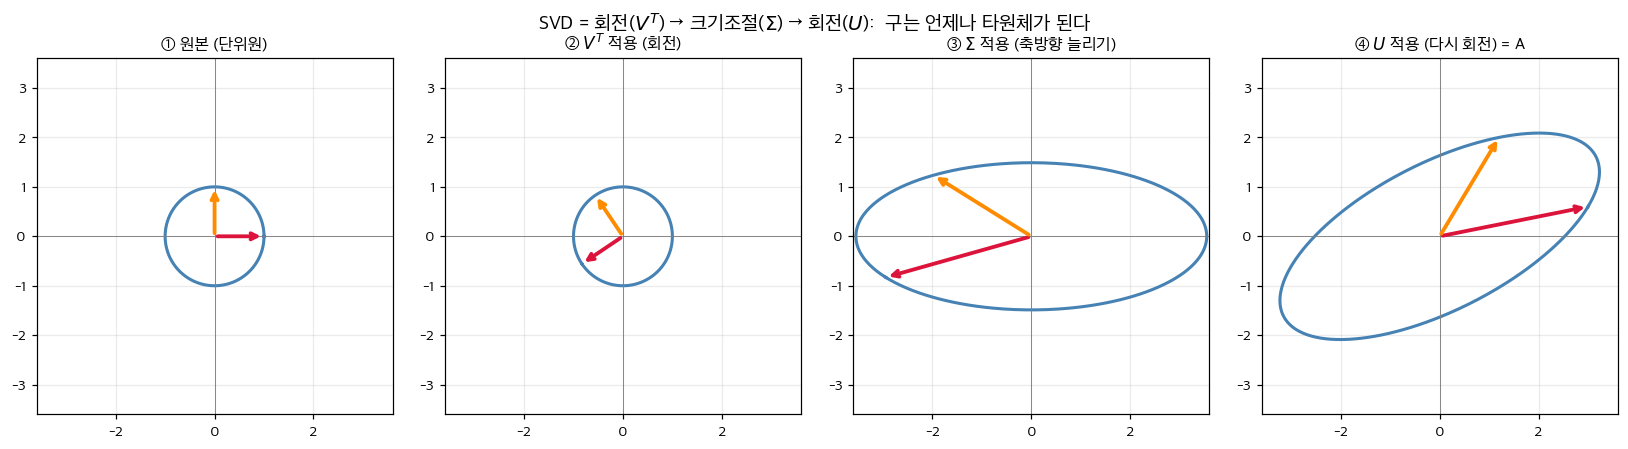

특이값 σ = [3.5475 1.4884]  <- 마지막 타원의 긴 반축 / 짧은 반축 길이
타원 위 점들의 원점까지 최대 거리 = 3.5475
타원 위 점들의 원점까지 최소 거리 = 1.4884


In [8]:
A2 = np.array([[3.0, 1.2],
               [0.6, 2.0]])
U2, S2, V2t = np.linalg.svd(A2)

theta = np.linspace(0, 2 * np.pi, 400)
circle = np.stack([np.cos(theta), np.sin(theta)])      # (2, 400) 단위원
basis = np.eye(2)                                       # 기준 축 2개(색으로 추적)

stages = [
    ("① 원본 (단위원)",            circle,                         basis),
    ("② $V^T$ 적용 (회전)",        V2t @ circle,                   V2t @ basis),
    ("③ $\\Sigma$ 적용 (축방향 늘리기)", np.diag(S2) @ V2t @ circle, np.diag(S2) @ V2t @ basis),
    ("④ $U$ 적용 (다시 회전) = A", A2 @ circle,                    A2 @ basis),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.9))
for ax, (title, pts, bas) in zip(axes, stages):
    ax.plot(pts[0], pts[1], lw=2, color="steelblue")
    for i, c in enumerate(["crimson", "darkorange"]):
        ax.annotate("", xy=bas[:, i], xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", lw=2.5, color=c))
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-3.6, 3.6); ax.set_ylim(-3.6, 3.6)
    ax.set_aspect("equal"); ax.grid(alpha=0.25)
    ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)

fig.suptitle("SVD = 회전($V^T$) → 크기조절($\\Sigma$) → 회전($U$):  구는 언제나 타원체가 된다", fontsize=13)
plt.tight_layout(); plt.show()

print("특이값 σ =", np.round(S2, 4), " <- 마지막 타원의 긴 반축 / 짧은 반축 길이")
print("타원 위 점들의 원점까지 최대 거리 =", np.round(np.linalg.norm(A2 @ circle, axis=0).max(), 4))
print("타원 위 점들의 원점까지 최소 거리 =", np.round(np.linalg.norm(A2 @ circle, axis=0).min(), 4))

## 2️⃣ 세 조각 각각의 의미 + 핵심 등식 `A vᵢ = σᵢ uᵢ`

### 📐 개념

| 조각 | 정체 | 기하학적 의미 |
| --- | --- | --- |
| **오른쪽 특이벡터** (V의 열) | 입력 공간 `ℝⁿ`의 **정규직교 기저** | 이 방향으로 들어가면 출력에서 **서로 직교하는 방향**으로 나온다. **정의역의 자연스러운 좌표계.** |
| **특이값** (Σ의 대각) | 배율 | `i`번째 오른쪽 특이벡터 방향을 **몇 배 늘리는지**. `σ=0`이면 그 방향은 **완전히 뭉갠다**. |
| **왼쪽 특이벡터** (U의 열) | 출력 공간 `ℝᵐ`의 **정규직교 기저** | `i`번째 오른쪽 특이벡터가 (배율 적용 후) **도착하는 방향**. |

이 셋을 하나로 묶는 **핵심 등식**:

```
A · vᵢ  =  σᵢ · uᵢ

"행렬 A는 i번째 오른쪽 특이벡터 vᵢ를 가져다가,
 σᵢ 배 늘려서, i번째 왼쪽 특이벡터 uᵢ 방향에 꽂아 놓는다."
```

이 한 줄이 **어떤 행렬이든 좌표 하나하나 무슨 일을 하는지** 완전히 설명한다.

### 🎬 현실 예시 — '로맨스 취향 축'은 어떻게 생기나?

영화 평점 행렬을 생각하자.

```
          액션1  액션2  로맨스1  로맨스2  로맨스3
사용자A     5     4      1       1       2
사용자B     4     5      1       2       1
사용자C     1     1      5       4       5
사용자D     2     1      4       5       4
```

사람이 직접 만든 “로맨스 축”은 이렇게 생긴 벡터일 수 있다.

```
[0, 0, 1, 1, 1]
```

하지만 SVD는 장르 이름을 미리 모른다. 대신 평점이 같이 움직이는 방향을 보고 이런 `vᵢ`를 찾을 수 있다.

```
vᵢ ≈ [-0.45, -0.48, 0.43, 0.46, 0.40]
```

앞의 두 영화와 뒤의 세 영화가 반대 부호로 갈라져 있으니, 사람이 나중에 “이 축은 액션 vs 로맨스 취향 같네”라고 해석한다. 이때 대응되는 `σᵢ`가 크면, 그 취향 축이 전체 평점 관계에서 중요한 패턴이라는 뜻이다.

> 핵심: SVD는 축 이름을 주지 않는다. **벡터를 먼저 찾고, 사람은 그 벡터의 큰 양수/음수 항목을 보며 의미를 붙인다.**



In [9]:
A = rng.standard_normal((5, 4))
U, S, Vt = np.linalg.svd(A, full_matrices=False)
V = Vt.T

print("A vᵢ  vs  σᵢ uᵢ  검증")
print("-" * 46)
for i in range(len(S)):
    left  = A @ V[:, i]          # A vᵢ
    right = S[i] * U[:, i]       # σᵢ uᵢ
    print(f"i={i}  σ={S[i]:.4f}   ‖A vᵢ - σᵢ uᵢ‖ = {np.linalg.norm(left - right):.2e}")

# vᵢ들은 서로 직교 -> A로 보낸 결과도 서로 직교한다(이게 '자연스러운 좌표계'의 뜻)
AV = A @ V
G = AV.T @ AV                    # 대각 성분만 남으면 = 서로 직교
print("\n(A V)ᵀ(A V) 의 비대각 성분 최대값:", np.abs(G - np.diag(np.diag(G))).max())
print("(A V)ᵀ(A V) 의 대각 성분:", np.round(np.diag(G), 4))
print("σᵢ² 값들            :", np.round(S**2, 4), " <- 정확히 일치")

A vᵢ  vs  σᵢ uᵢ  검증
----------------------------------------------
i=0  σ=2.7493   ‖A vᵢ - σᵢ uᵢ‖ = 1.85e-15
i=1  σ=2.0371   ‖A vᵢ - σᵢ uᵢ‖ = 1.36e-15
i=2  σ=0.6231   ‖A vᵢ - σᵢ uᵢ‖ = 3.44e-16
i=3  σ=0.3904   ‖A vᵢ - σᵢ uᵢ‖ = 3.92e-16

(A V)ᵀ(A V) 의 비대각 성분 최대값: 4.916059749683708e-15
(A V)ᵀ(A V) 의 대각 성분: [7.5587 4.1497 0.3883 0.1524]
σᵢ² 값들            : [7.5587 4.1497 0.3883 0.1524]  <- 정확히 일치


## 3️⃣ 외적(rank-1) 합 형태 — "레이어로 쌓기"

### 🧸 비유

그림 그리기를 생각하자. 처음엔 **큰 붓으로 배경 색**을 칠한다(가장 중요한 패턴). 그다음 **중간 붓으로 형태**를 잡고, 마지막에 **얇은 붓으로 잔털 디테일**을 그린다.

SVD는 행렬을 정확히 이렇게 **"붓질 레이어"** 로 분해한다. 그리고 **큰 붓질부터 순서대로** 정렬해 준다.

### 📐 개념

```
A = σ₁ u₁ v₁ᵀ + σ₂ u₂ v₂ᵀ + … + σ_r u_r v_rᵀ

각 항 σᵢ uᵢ vᵢᵀ 는 rank-1 행렬 (외적, outer product).
전체 행렬은 r개의 rank-1 행렬의 합. (r = rank(A))
```

- 첫 항이 **가장 중요한 패턴 하나**를 담는다.
- 둘째 항이 **그다음으로 중요한 패턴**을 담는다.
- 이 합을 중간에 **끊으면(truncate)** → 그 계수(rank)에서 **가능한 최선의 근사**가 된다.

```
rank-1 근사:  A₁ = σ₁u₁v₁ᵀ                    (지배적 패턴 하나)
rank-2 근사:  A₂ = σ₁u₁v₁ᵀ + σ₂u₂v₂ᵀ          (중요한 패턴 둘)
rank-k 근사:  A_k = 상위 k개 항의 합            (Eckart–Young에 의해 최적)
```

In [10]:
A = rng.standard_normal((6, 5))
U, S, Vt = np.linalg.svd(A, full_matrices=False)

# 외적을 하나씩 더해 가며 원본에 얼마나 가까워지는지
acc = np.zeros_like(A)
print("항을 하나씩 더할 때마다 남는 오차")
print("-" * 52)
for i in range(len(S)):
    layer = S[i] * np.outer(U[:, i], Vt[i, :])   # σᵢ uᵢ vᵢᵀ  (rank-1)
    acc = acc + layer
    print(f"k={i+1}  σ={S[i]:.4f}  layer의 rank={np.linalg.matrix_rank(layer)}  "
          f"‖A - A_k‖_F = {np.linalg.norm(A - acc):.6f}")

print("\n마지막까지 다 더하면 원본과 완전히 같아진다:",
      np.allclose(acc, A))

항을 하나씩 더할 때마다 남는 오차
----------------------------------------------------
k=1  σ=3.0605  layer의 rank=1  ‖A - A_k‖_F = 2.491258
k=2  σ=1.6386  layer의 rank=1  ‖A - A_k‖_F = 1.876515
k=3  σ=1.3774  layer의 rank=1  ‖A - A_k‖_F = 1.274409
k=4  σ=1.1321  layer의 rank=1  ‖A - A_k‖_F = 0.585223
k=5  σ=0.5852  layer의 rank=1  ‖A - A_k‖_F = 0.000000

마지막까지 다 더하면 원본과 완전히 같아진다: True


### 🖼️ 그림 2 — 레이어를 쌓아 원본이 만들어지는 모습

왼쪽부터: rank-1 항 하나 → 두 개 누적 → 세 개 누적 … → 전부(=원본).
**의도적으로 rank가 낮은(=구조가 있는) 행렬**을 쓰면 몇 개만 쌓아도 원본과 거의 같아진다.

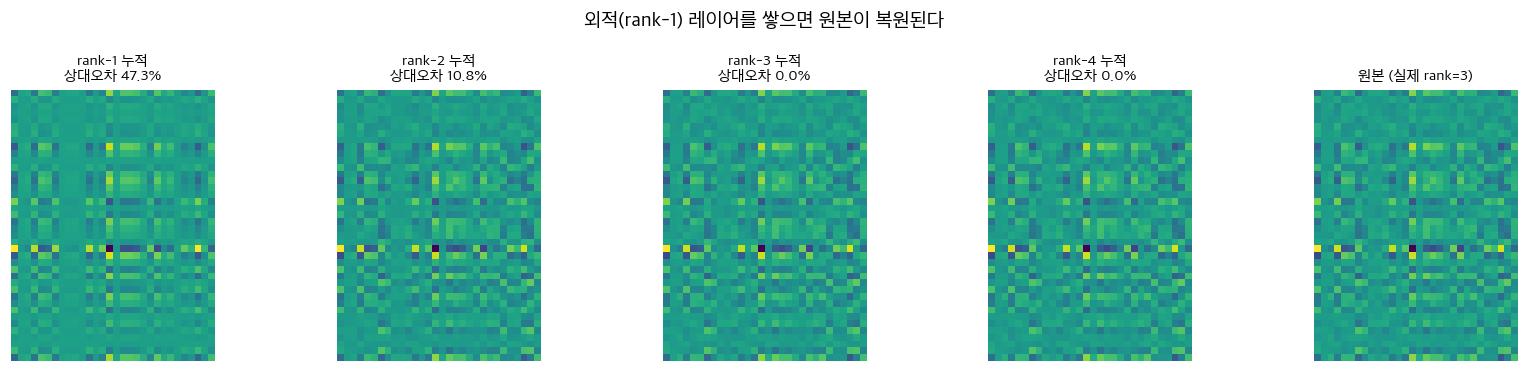

특이값: [282.8138 148.0448  34.5545   0.       0.       0.    ]  <- 4번째부터 사실상 0 (진짜 rank가 3이므로)


In [11]:
# 실제로는 rank 3인 40x30 행렬을 만든다(눈에 보이는 구조를 넣음)
r_true = 3
Ut = rng.standard_normal((40, r_true))
Vt_ = rng.standard_normal((r_true, 30))
M = Ut @ np.diag([9.0, 4.0, 1.5]) @ Vt_

U, S, VT = np.linalg.svd(M, full_matrices=False)

fig, axes = plt.subplots(1, 5, figsize=(15, 3.4))
acc = np.zeros_like(M)
for j, ax in enumerate(axes[:4]):
    acc = acc + S[j] * np.outer(U[:, j], VT[j, :])
    ax.imshow(acc, cmap="viridis")
    err = np.linalg.norm(M - acc) / np.linalg.norm(M)
    ax.set_title(f"rank-{j+1} 누적\n상대오차 {err:.1%}", fontsize=10)
    ax.axis("off")
axes[4].imshow(M, cmap="viridis"); axes[4].set_title("원본 (실제 rank=3)", fontsize=10); axes[4].axis("off")
fig.suptitle("외적(rank-1) 레이어를 쌓으면 원본이 복원된다", fontsize=13)
plt.tight_layout(); plt.show()

print("특이값:", np.round(S[:6], 6), " <- 4번째부터 사실상 0 (진짜 rank가 3이므로)")

## 4️⃣ 잘린 SVD(Truncated SVD)와 Eckart–Young–Mirsky 정리

### 📐 개념

상위 `k`개만 남기는 것을 **잘린 SVD**라 한다.

```
A_k = U_k · Σ_k · V_kᵀ

  U_k     : m x k   (U의 앞 k개 열)
  Σ_k     : k x k   (Σ의 좌상단 k x k 블록)
  V_k     : n x k   (V의 앞 k개 열)

근사 오차 = σ_{k+1}                                (스펙트럼 노름)
          = sqrt(σ_{k+1}² + … + σ_r²)              (프로베니우스 노름)
```

> **Eckart–Young–Mirsky 정리:** 이것은 그냥 "괜찮은" 근사가 아니라, **rank가 k인 모든 행렬 중에서 원본에 가장 가까운 행렬**이다. 프로베니우스 노름과 스펙트럼 노름 **둘 다에서** 최적이다. 더 잘하는 rank-k 행렬은 **존재하지 않는다.**

| 성분 | 상대적 크기 | rank-3 근사에 남나? |
| --- | --- | --- |
| σ₁ | 가장 큼 | ✅ |
| σ₂ | 큼 | ✅ |
| σ₃ | 중간~큼 | ✅ |
| σ₄ | 중간 | ❌ (오차가 됨) |
| σ₅ | 중간~작음 | ❌ |
| σ₆ | 작음 | ❌ |
| σ₇ | 아주 작음 | ❌ |
| σ₈ | 극소 | ❌ |

상위 3개를 남기면 `A₃`가 가장 큰 특이값 세 개를 담고, **나머지(σ₄~σ₈)가 통째로 오차**가 된다.

> 💡 **특이값이 빨리 줄어들면** 작은 `k`로도 행렬 대부분을 담을 수 있다.
> **천천히 줄어들면** 그 행렬엔 저계수(low-rank) 구조가 **없다**는 뜻이다.

In [12]:
def truncate(A, k):
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

A = rng.standard_normal((30, 20))
U, S, Vt = np.linalg.svd(A, full_matrices=False)

print("오차 공식이 정확히 맞는지 확인")
print("-" * 74)
print(f"{'k':>2} | {'실제 ‖A-A_k‖_F':>15} | {'√(σ_{k+1}²+…)':>15} | {'실제 스펙트럼':>13} | {'σ_{k+1}':>9}")
for k in [1, 3, 5, 10, 15]:
    Ak = truncate(A, k)
    fro_actual = np.linalg.norm(A - Ak)
    fro_theory = np.sqrt(np.sum(S[k:] ** 2))
    spec_actual = np.linalg.norm(A - Ak, 2)
    print(f"{k:>2} | {fro_actual:>15.8f} | {fro_theory:>15.8f} | {spec_actual:>13.8f} | {S[k]:>9.6f}")

오차 공식이 정확히 맞는지 확인
--------------------------------------------------------------------------
 k |    실제 ‖A-A_k‖_F |   √(σ_{k+1}²+…) |       실제 스펙트럼 |   σ_{k+1}
 1 |     22.51504998 |     22.51504998 |    8.92498157 |  8.924982
 3 |     19.02978260 |     19.02978260 |    7.70884398 |  7.708844
 5 |     15.87471120 |     15.87471120 |    6.86633602 |  6.866336
10 |      9.56975455 |      9.56975455 |    4.39011736 |  4.390117
15 |      4.44420970 |      4.44420970 |    2.65992765 |  2.659928


In [13]:
# Eckart-Young 정리를 '실험'으로 확인:
# 무작위 rank-k 행렬을 20000개 만들어 봐도, 잘린 SVD보다 가까운 것은 하나도 없다.
k = 3
A_k = truncate(A, k)
best_svd = np.linalg.norm(A - A_k)

best_random = np.inf
for _ in range(20000):
    B = rng.standard_normal((30, k)) @ rng.standard_normal((k, 20))   # 임의의 rank-3 행렬
    best_random = min(best_random, np.linalg.norm(A - B))

# 조금 더 공정하게: 무작위 시작점에서 교대최소제곱으로 '최적화'까지 해본다
B = rng.standard_normal((30, k))
for _ in range(300):
    C = np.linalg.lstsq(B, A, rcond=None)[0]        # B 고정하고 C 최적화
    B = np.linalg.lstsq(C.T, A.T, rcond=None)[0].T  # C 고정하고 B 최적화
best_als = np.linalg.norm(A - B @ C)

print(f"잘린 SVD (rank-{k})     : {best_svd:.8f}   <- 이론상 최적")
print(f"무작위 rank-{k} 2만 개 중 최선: {best_random:.8f}")
print(f"교대최소제곱 최적화 결과    : {best_als:.8f}")
print(f"\nSVD가 최적인가? {best_svd <= best_random + 1e-9 and best_svd <= best_als + 1e-6}")

잘린 SVD (rank-3)     : 19.02978260   <- 이론상 최적
무작위 rank-3 2만 개 중 최선: 32.26088467
교대최소제곱 최적화 결과    : 19.02978260

SVD가 최적인가? True


## 5️⃣ 고유분해와의 관계, 그리고 수치 안정성

### 🧲 직관 — σ는 어떻게 측정하나?

특이값 `σᵢ`는 **행렬 `A`가 어떤 방향을 몇 배 늘리는지**를 측정한 값이다.

벡터 `v`를 `A`에 넣었을 때 길이가 얼마나 커졌는지는 `||Av||`로 볼 수 있다. 길이의 제곱으로 쓰면:

```
||Av||² = (Av)ᵀ(Av) = vᵀ AᵀA v
```

그래서 `AᵀA`는 **입력 방향별로 `A`가 길이를 얼마나 키우는지**를 담은 행렬이다. 이 행렬의 고유벡터가 바로 오른쪽 특이벡터 `vᵢ`이고, 고유값은 늘어난 길이의 제곱이다.

```
AᵀA vᵢ = λᵢ vᵢ
σᵢ = sqrt(λᵢ)
```

즉, 여기서 고유값 이야기가 다시 나온다. **고유값 `λᵢ`는 `σᵢ²`, 특이값 `σᵢ`는 그 제곱근**이다.

### 📐 개념 — SVD는 `AᵀA`, `AAᵀ`의 고유분해에서 나온다

```
AᵀA = V Σᵀ Uᵀ U Σ Vᵀ
    = V Σᵀ Σ Vᵀ
    = V D Vᵀ            (D = ΣᵀΣ : 대각에 σᵢ² 이 들어간 대각행렬)

  → 오른쪽 특이벡터 V = AᵀA 의 고유벡터
  → 특이값의 제곱 σᵢ²  = AᵀA 의 고유값

AAᵀ = U Σ Vᵀ V Σᵀ Uᵀ
    = U Σ Σᵀ Uᵀ

  → 왼쪽 특이벡터 U = AAᵀ 의 고유벡터
  → AAᵀ 의 고유값도 역시 σᵢ²
```

이 연결에서 **세 가지 사실**이 따라온다.

1. **특이값은 항상 실수이고 음이 아니다.** (양의 준정부호 행렬의 고유값의 제곱근이므로)
2. `AᵀA`의 고유분해로 SVD를 **계산할 수는 있지만**, 그러면 **조건수가 제곱되어** 수치 정밀도를 잃는다. 전용 SVD 알고리즘은 이 경로를 피한다.
3. `A`가 **정사각 대칭 양의 준정부호**이면, SVD와 고유분해는 **완전히 같은 것**이다.

### ⚠️ 수치 안정성 — 조건수가 제곱된다

```
예시:
  A의 특이값 = [1000, 1, 0.001]
  A의 조건수 = 1000 / 0.001 = 10⁶

  AᵀA의 고유값 = [10⁶, 1, 10⁻⁶]
  AᵀA의 조건수 = 10⁶ / 10⁻⁶ = 10¹²

  SVD 직접 계산  : 조건수 10⁶ 으로 작업
  AᵀA 경유 계산 : 조건수 10¹² 으로 작업  (정밀도 6자리 추가 손실)
```

> 현대 SVD 알고리즘(**Golub–Kahan 이중대각화**)은 `A`에서 **직접** 작업하며 `AᵀA`를 절대 만들지 않는다.
> 그래서 **언제나 `np.linalg.svd(A)` 를 쓰고, `np.linalg.eig(A.T @ A)` 는 쓰지 말아야 한다.**

In [14]:
# (1) V가 AᵀA의 고유벡터이고, σ²이 그 고유값임을 확인
A = rng.standard_normal((6, 4))
U, S, Vt = np.linalg.svd(A, full_matrices=False)

evals_ata, evecs_ata = np.linalg.eigh(A.T @ A)         # 대칭 -> eigh
order = np.argsort(evals_ata)[::-1]
evals_ata, evecs_ata = evals_ata[order], evecs_ata[:, order]

print("σ²          =", np.round(S**2, 6))
print("AᵀA의 고유값 =", np.round(evals_ata, 6), " -> 일치:", np.allclose(S**2, evals_ata))

# 고유벡터는 부호가 반대일 수 있으므로 |내적|으로 비교
align = np.abs(np.sum(evecs_ata * Vt.T, axis=0))
print("V의 열 vs AᵀA 고유벡터의 |내적| =", np.round(align, 6), "(1이면 같은 방향)")

evals_aat = np.sort(np.linalg.eigvalsh(A @ A.T))[::-1]
print("\nAAᵀ의 고유값 =", np.round(evals_aat[:4], 6), " -> 역시 σ²과 일치")

# (3) 대칭 양의 준정부호 행렬에서는 SVD == 고유분해
P = A.T @ A
w = np.sort(np.linalg.eigvalsh(P))[::-1]
s = np.linalg.svd(P, compute_uv=False)
print("\n대칭 PSD 행렬: 고유값 =", np.round(w, 4))
print("                특이값 =", np.round(s, 4), " -> 같음:", np.allclose(w, s))

σ²          = [14.9051  8.7221  1.6526  1.3484]
AᵀA의 고유값 = [14.9051  8.7221  1.6526  1.3484]  -> 일치: True
V의 열 vs AᵀA 고유벡터의 |내적| = [1. 1. 1. 1.] (1이면 같은 방향)

AAᵀ의 고유값 = [14.9051  8.7221  1.6526  1.3484]  -> 역시 σ²과 일치

대칭 PSD 행렬: 고유값 = [14.9051  8.7221  1.6526  1.3484]
                특이값 = [14.9051  8.7221  1.6526  1.3484]  -> 같음: True


In [15]:
# 조건수 제곱으로 인한 정밀도 손실을 실제로 재현한다
Q1, _ = np.linalg.qr(rng.standard_normal((3, 3)))
Q2, _ = np.linalg.qr(rng.standard_normal((3, 3)))
sig_true = np.array([1000.0, 1.0, 0.001])
A_ill = Q1 @ np.diag(sig_true) @ Q2.T

print("참값 σ           :", sig_true)
print("A의 조건수        : %.1e" % (sig_true[0] / sig_true[-1]))
print("AᵀA의 조건수      : %.1e   <- 제곱됨" % ((sig_true[0] / sig_true[-1]) ** 2))

sig_svd = np.linalg.svd(A_ill, compute_uv=False)
sig_ata = np.sqrt(np.clip(np.sort(np.linalg.eigvalsh(A_ill.T @ A_ill))[::-1], 0, None))

print("\nSVD 직접 계산     :", sig_svd)
print("AᵀA 경유 계산     :", sig_ata)
print("\n가장 작은 σ의 상대오차")
print(f"  SVD 직접 : {abs(sig_svd[-1]  - 0.001) / 0.001:.3e}")
print(f"  AᵀA 경유 : {abs(sig_ata[-1] - 0.001) / 0.001:.3e}   <- 훨씬 나쁨")

참값 σ           : [1000.       1.       0.001]
A의 조건수        : 1.0e+06
AᵀA의 조건수      : 1.0e+12   <- 제곱됨

SVD 직접 계산     : [1000.       1.       0.001]
AᵀA 경유 계산     : [1000.       1.       0.001]

가장 작은 σ의 상대오차
  SVD 직접 : 1.721e-11
  AᵀA 경유 : 8.437e-06   <- 훨씬 나쁨


## 6️⃣ 🏭 실무 1 — 이미지 압축

### 🧸 비유

멀리서 보면 그림의 **큰 형태와 색 덩어리**만 보인다. 가까이 갈수록 **잔털·질감**이 보인다.
SVD는 그림을 "멀리서 보이는 것 → 가까이서 보이는 것" 순으로 정렬해 주고, **뒤쪽 잔털을 잘라내면 그게 압축**이다.

### 📐 개념 — 저장 용량 계산

흑백 이미지는 곧 픽셀 밝기 행렬이다. 800×600 이미지는 480,000개의 숫자다.

```
원본 이미지: 800 x 600 = 480,000 개 값

rank k 의 SVD:
  U_k      : 800 x k 개 값
  Σ_k      : k 개 값
  V_k      : 600 x k 개 값
  합계     : k * (800 + 600 + 1) = k * 1401 개 값

  k=10  :  14,010 개  (원본의  2.9%)
  k=50  :  70,050 개  (원본의 14.6%)
  k=100 : 140,100 개  (원본의 29.2%)

  k가 작을수록 압축률은 좋아지지만 화질은 나빠진다.
```

**핵심 통찰:** 자연 이미지는 특이값이 **아주 빠르게 감소**한다. 앞쪽 특이값들이 큰 구조(형태·명암 변화)를 담고, 뒤쪽은 미세 디테일과 노이즈를 담는다. rank 50 정도로 잘라도 원본과 거의 구별되지 않으면서 저장량은 **85% 절약**되는 경우가 흔하다.

In [16]:
import matplotlib.cbook as cbook

# matplotlib에 내장된 실제 사진(그레이스 호퍼 제독)을 흑백으로 변환해 사용
img_rgb = plt.imread(cbook.get_sample_data("grace_hopper.jpg")).astype(float) / 255.0
img = img_rgb @ np.array([0.2989, 0.5870, 0.1140])     # 흑백 변환
rows, cols = img.shape
print(f"이미지 크기: {rows} x {cols} = {rows*cols:,} 개 픽셀")

def compress_image_svd(image_matrix, k):
    U, S, Vt = np.linalg.svd(image_matrix, full_matrices=False)
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

print(f"\n{'k':>4} | {'상대오차':>9} | {'저장 비율':>9} | {'절약':>7}")
print("-" * 40)
for k in [1, 5, 10, 25, 50, 100]:
    comp = compress_image_svd(img, k)
    error = np.linalg.norm(img - comp) / np.linalg.norm(img)
    ratio = k * (rows + cols + 1) / (rows * cols)
    print(f"{k:>4} | {error:>9.4f} | {ratio:>8.1%} | {1-ratio:>6.1%}")

이미지 크기: 600 x 512 = 307,200 개 픽셀

   k |      상대오차 |     저장 비율 |      절약
----------------------------------------
   1 |    0.5184 |     0.4% |  99.6%
   5 |    0.3465 |     1.8% |  98.2%
  10 |    0.2651 |     3.6% |  96.4%
  25 |    0.1687 |     9.1% |  90.9%
  50 |    0.1090 |    18.1% |  81.9%
 100 |    0.0624 |    36.2% |  63.8%


### 🖼️ 그림 3 — rank를 올려 가며 보는 화질

**"몇 번째 rank부터 눈으로 봐줄 만한가?"** 를 직접 판단해 보자. (연습문제 2번의 답이기도 하다)

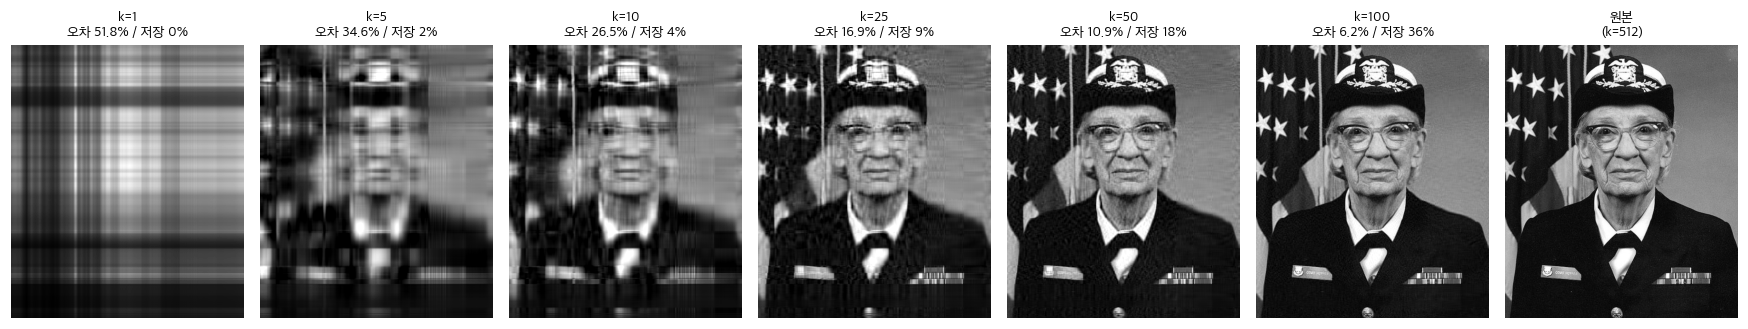

In [17]:
ks = [1, 5, 10, 25, 50, 100]
fig, axes = plt.subplots(1, len(ks) + 1, figsize=(16, 3.4))
for ax, k in zip(axes, ks):
    comp = compress_image_svd(img, k)
    err = np.linalg.norm(img - comp) / np.linalg.norm(img)
    ratio = k * (rows + cols + 1) / (rows * cols)
    ax.imshow(np.clip(comp, 0, 1), cmap="gray")
    ax.set_title(f"k={k}\n오차 {err:.1%} / 저장 {ratio:.0%}", fontsize=9)
    ax.axis("off")
axes[-1].imshow(img, cmap="gray"); axes[-1].set_title("원본\n(k=512)", fontsize=9); axes[-1].axis("off")
plt.tight_layout(); plt.show()

### 🖼️ 그림 4 — 특이값 감소 속도가 압축 가능성을 결정한다

**실제 사진**과 **완전 무작위 행렬**의 특이값 스펙트럼을 비교한다.
- 사진: 특이값이 **뚝 떨어진다** → 저계수 구조 있음 → **압축 잘 됨**
- 무작위: **완만하게** 떨어진다 → 저계수 구조 없음 → **압축 안 됨**

> ⚠️ 원문 Step 3 예제는 `np.random.randn(200, 300)` 즉 **무작위 행렬**을 압축한다.
> 무작위 행렬은 저계수 구조가 없어 오차가 거의 줄지 않는다 — **"SVD 압축이 언제 안 통하는가"** 를 보여주는 좋은 반례다.

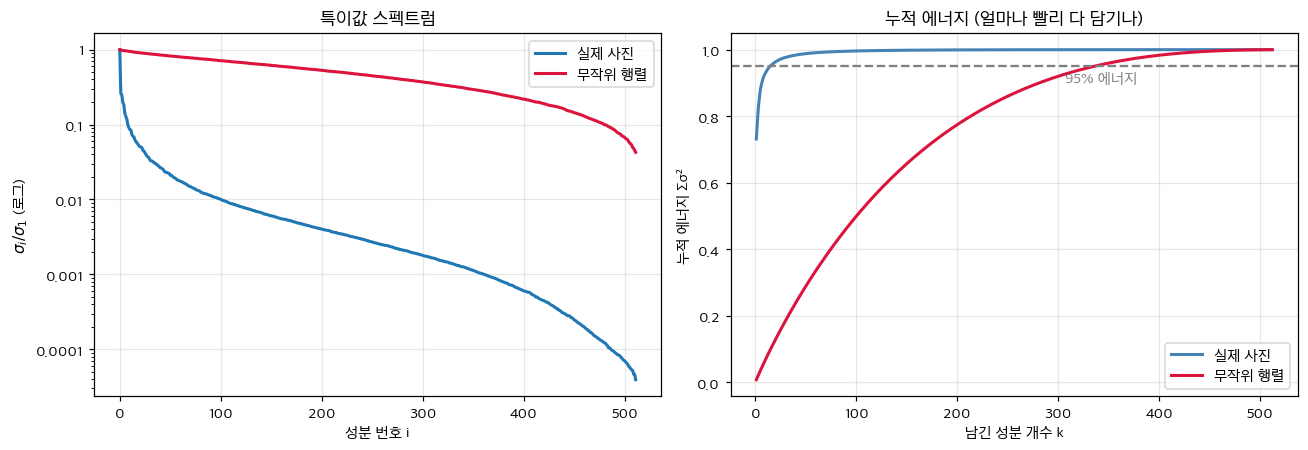

에너지 95%를 담는 데 필요한 k — 사진: 15개 / 전체 512개
에너지 95%를 담는 데 필요한 k — 무작위: 336개 / 전체 512개  <- 거의 다 필요 = 압축 불가

[원문 Step 3 재현 — 무작위 200x300 행렬]
  k=  1  오차=0.9918  저장=0.8%  <- 오차가 거의 안 줄어든다
  k=  5  오차=0.9611  저장=4.2%  <- 오차가 거의 안 줄어든다
  k= 10  오차=0.9249  저장=8.3%  <- 오차가 거의 안 줄어든다
  k= 20  오차=0.8563  저장=16.7%  <- 오차가 거의 안 줄어든다
  k= 50  오차=0.6719  저장=41.8%  <- 오차가 거의 안 줄어든다


In [18]:
S_img  = np.linalg.svd(img, compute_uv=False)
noise_m = rng.standard_normal((rows, cols))
S_rand = np.linalg.svd(noise_m, compute_uv=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].semilogy(S_img / S_img[0], label="실제 사진", lw=2)
ax[0].semilogy(S_rand / S_rand[0], label="무작위 행렬", lw=2, color="crimson")
plain_log(ax[0])
ax[0].set_xlabel("성분 번호 i"); ax[0].set_ylabel("$\\sigma_i / \\sigma_1$ (로그)")
ax[0].set_title("특이값 스펙트럼"); ax[0].legend(); ax[0].grid(alpha=0.3)

for name, Sv, c in [("실제 사진", S_img, "steelblue"), ("무작위 행렬", S_rand, "crimson")]:
    energy = np.cumsum(Sv**2) / np.sum(Sv**2)
    ax[1].plot(np.arange(1, len(Sv) + 1), energy, lw=2, color=c, label=name)
ax[1].axhline(0.95, ls="--", color="gray"); ax[1].text(len(S_img)*0.6, 0.90, "95% 에너지", color="gray")
ax[1].set_xlabel("남긴 성분 개수 k"); ax[1].set_ylabel("누적 에너지 Σσ²")
ax[1].set_title("누적 에너지 (얼마나 빨리 다 담기나)"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

k95_img  = np.searchsorted(np.cumsum(S_img**2)/np.sum(S_img**2), 0.95) + 1
k95_rand = np.searchsorted(np.cumsum(S_rand**2)/np.sum(S_rand**2), 0.95) + 1
print(f"에너지 95%를 담는 데 필요한 k — 사진: {k95_img}개 / 전체 {len(S_img)}개")
print(f"에너지 95%를 담는 데 필요한 k — 무작위: {k95_rand}개 / 전체 {len(S_rand)}개  <- 거의 다 필요 = 압축 불가")

# 원문 Step 3 재현: 무작위 행렬은 압축이 사실상 안 된다
print("\n[원문 Step 3 재현 — 무작위 200x300 행렬]")
img_rand = rng.standard_normal((200, 300))
for k in [1, 5, 10, 20, 50]:
    c = compress_image_svd(img_rand, k)
    e = np.linalg.norm(img_rand - c) / np.linalg.norm(img_rand)
    print(f"  k={k:>3d}  오차={e:.4f}  저장={k*(200+300+1)/(200*300):.1%}  <- 오차가 거의 안 줄어든다")

## 7️⃣ 🏭 실무 2 — 노이즈 제거

### 🧸 비유

라디오에서 **노래(신호)** 는 크게 나오고 **지직거리는 잡음** 은 작게 깔린다.
볼륨이 일정 수준 이하인 소리를 통째로 잘라내면 노래는 살고 잡음만 사라진다.

### 📐 개념

노이즈가 낀 데이터는 **신호가 상위 특이값에 몰려 있고**, **노이즈는 모든 특이값에 얇게 퍼진다**. 그래서 잘라내면 노이즈 바닥이 제거된다.

**깨끗한 신호의 특이값**

| 성분 | 크기 | 정체 |
| --- | --- | --- |
| σ₁ | 아주 큼 | 신호 |
| σ₂ | 큼 | 신호 |
| σ₃ | 중간 | 신호 |
| σ₄ | 거의 0 | 무시 가능 |
| σ₅ | 거의 0 | 무시 가능 |

**노이즈가 낀 신호의 특이값** (노이즈가 전부에 더해진다)

| 성분 | 크기 | 정체 |
| --- | --- | --- |
| σ₁ | 아주 큼 | 신호 |
| σ₂ | 큼 | 신호 |
| σ₃ | 중간 | 신호 |
| σ₄ | 작음 | 노이즈 |
| σ₅ | 작음 | 노이즈 |
| σ₆ | 작음 | 노이즈 |
| σ₇ | 작음 | 노이즈 |

판정 흐름:

```
        모든 특이값
             │
      뚜렷한 계단(gap)이 있나?
        ├── gap 위쪽 → 신호: 상위 k개를 남긴다
        └── gap 아래쪽 → 노이즈: 버린다
                            │
                    A_k 로 복원 = 노이즈 제거본
```

**실무 용처:** 신호처리, 과학 측정 데이터 정제, 데이터 클리닝. **가법 노이즈로 오염된 행렬**이라면 잘린 SVD는 신호와 노이즈를 분리하는 **원리에 기반한** 방법이다.

In [19]:
# 원문 Step 4 재현
np.random.seed(42)
clean = np.outer(np.sin(np.linspace(0, 4*np.pi, 100)),
                 np.cos(np.linspace(0, 2*np.pi, 80)))
noise = 0.3 * np.random.randn(100, 80)
noisy = clean + noise

U, S, Vt = np.linalg.svd(noisy, full_matrices=False)
denoised = U[:, :5] @ np.diag(S[:5]) @ Vt[:5, :]

print(f"노이즈 데이터 오차 : {np.linalg.norm(noisy - clean):.4f}")
print(f"노이즈 제거 후 오차 : {np.linalg.norm(denoised - clean):.4f}")
print(f"개선율             : {(1 - np.linalg.norm(denoised - clean) / np.linalg.norm(noisy - clean)):.1%}")
print(f"\n참고: clean은 사실 rank {np.linalg.matrix_rank(clean)} 이다 (두 벡터의 외적이므로).")
print("특이값:", np.round(S[:8], 4), " <- 1개만 크고 나머지는 노이즈 바닥")

노이즈 데이터 오차 : 27.0248
노이즈 제거 후 오차 : 11.2097
개선율             : 58.5%

참고: clean은 사실 rank 1 이다 (두 벡터의 외적이므로).
특이값: [44.895   5.4894  5.3355  5.2251  5.119   4.9712  4.9153  4.8175]  <- 1개만 크고 나머지는 노이즈 바닥


### 🖼️ 그림 5 — 노이즈 제거 시각화 + "최적의 k 찾기"

특이값 그래프에서 **계단(gap)** 이 보이고, 그 지점이 실제로 오차를 최소화하는 `k`와 일치한다.

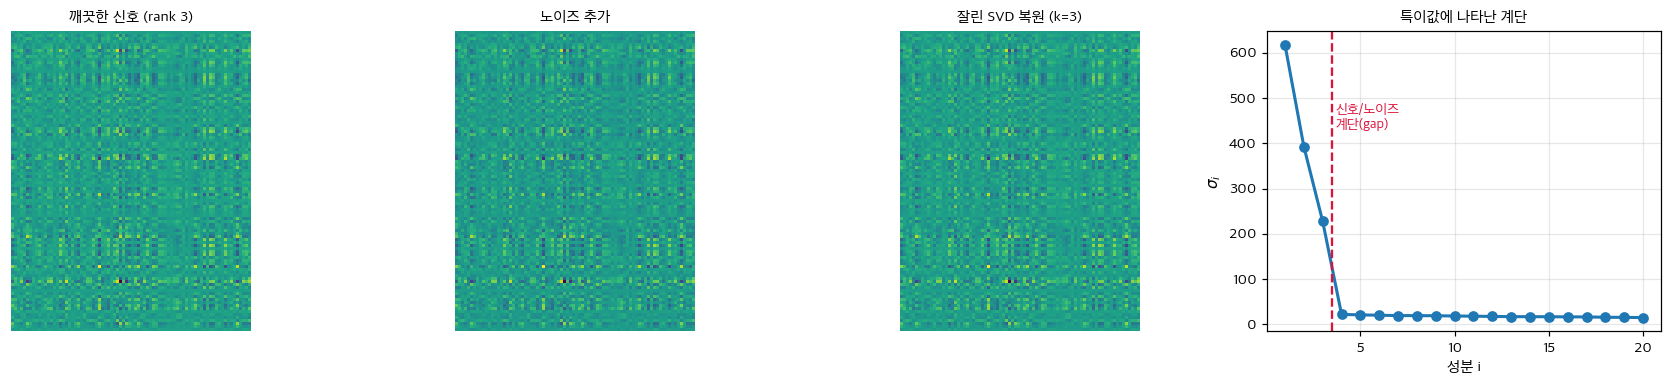

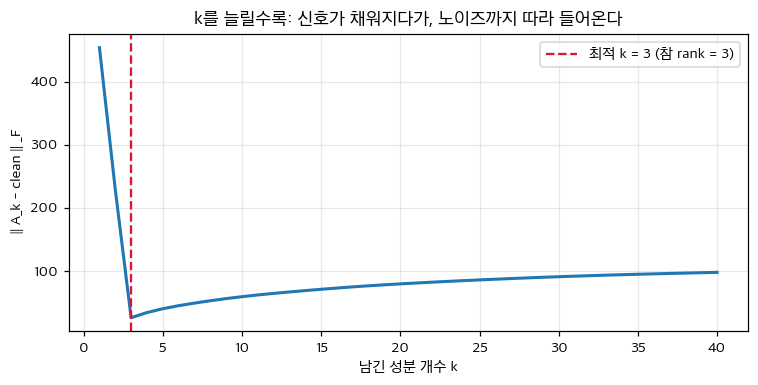

노이즈 원본 오차 : 106.137
k=3 복원 오차 : 26.103  (개선 75.4%)


In [20]:
# 조금 더 현실적인 rank-3 신호 + 노이즈
rng2 = np.random.default_rng(7)
r = 3
clean3 = (rng2.standard_normal((100, r)) * np.array([8., 5., 3.])) @ rng2.standard_normal((r, 80))
noisy3 = clean3 + 1.2 * rng2.standard_normal((100, 80))
S3 = np.linalg.svd(noisy3, compute_uv=False)

errs = [np.linalg.norm(truncate(noisy3, k) - clean3) for k in range(1, 41)]
k_opt = int(np.argmin(errs)) + 1

fig, ax = plt.subplots(1, 4, figsize=(16, 3.6))
ax[0].imshow(clean3, cmap="viridis"); ax[0].set_title("깨끗한 신호 (rank 3)", fontsize=10); ax[0].axis("off")
ax[1].imshow(noisy3, cmap="viridis"); ax[1].set_title("노이즈 추가", fontsize=10); ax[1].axis("off")
ax[2].imshow(truncate(noisy3, k_opt), cmap="viridis")
ax[2].set_title(f"잘린 SVD 복원 (k={k_opt})", fontsize=10); ax[2].axis("off")

ax[3].plot(np.arange(1, 21), S3[:20], "o-", lw=2)
ax[3].axvline(r + 0.5, ls="--", color="crimson")
ax[3].text(r + 0.7, S3[0]*0.7, "신호/노이즈\n계단(gap)", color="crimson", fontsize=9)
ax[3].set_xlabel("성분 i"); ax[3].set_ylabel("$\\sigma_i$"); ax[3].set_title("특이값에 나타난 계단", fontsize=10)
ax[3].grid(alpha=0.3)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(range(1, 41), errs, lw=2)
ax.axvline(k_opt, ls="--", color="crimson", label=f"최적 k = {k_opt} (참 rank = {r})")
ax.set_xlabel("남긴 성분 개수 k"); ax.set_ylabel("‖A_k - clean‖_F")
ax.set_title("k를 늘릴수록: 신호가 채워지다가, 노이즈까지 따라 들어온다")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"노이즈 원본 오차 : {np.linalg.norm(noisy3 - clean3):.3f}")
print(f"k={k_opt} 복원 오차 : {min(errs):.3f}  (개선 {(1-min(errs)/np.linalg.norm(noisy3-clean3)):.1%})")

## 8️⃣ 🏭 실무 3 — 추천 시스템 (잠재 요인)

### 🧸 비유

반 친구들의 **간식 취향**을 조사한다고 하자. 사람마다 다 다른 것 같지만, 실제로는 **"단맛 좋아함 / 짠맛 좋아함"** 같은 **몇 개의 축**으로 거의 다 설명된다.
새 과자가 나왔을 때, 그 축 위에서의 위치만 알면 **누가 좋아할지 예측**할 수 있다.

### 📐 개념

넷플릭스 프라이즈로 유명해진 문제다. 사용자-영화 평점 행렬은 **대부분이 비어 있다.**

```
             Movie1  Movie2  Movie3  Movie4  Movie5
  User1      [  5      ?       3       ?       1  ]
  User2      [  ?      4       ?       2       ?  ]
  User3      [  3      ?       5       ?       ?  ]
  User4      [  ?      ?       ?       4       3  ]

  ? = 알 수 없는 평점
```

**아이디어:** 이 평점 행렬은 **rank가 낮다**. 사람들의 취향은 완전히 독립적이지 않다. 액션 vs 드라마, 옛날 것 vs 최신 것, 머리 쓰는 것 vs 감각적인 것 같은 **소수의 잠재 요인(latent factor)** 이 대부분의 선호를 설명한다.

(빈칸을 채운) 평점 행렬에 SVD를 적용하면:
- `U` : **잠재 요인 공간에서의 사용자 프로필**
- `Σ` : **각 잠재 요인의 중요도**
- `Vᵀ` : **잠재 요인 공간에서의 영화 프로필**

어떤 사용자의 예측 평점 = **사용자 프로필 · 영화 프로필 내적** (특이값으로 가중). 저계수 근사가 **빈칸을 메워 준다.**

> 실무에서는 결측치를 직접 다루는 **Simon Funk의 증분 SVD**나 **ALS(교대최소제곱)** 같은 변형을 쓴다. 하지만 핵심 아이디어는 동일하다 — **SVD를 통한 잠재 요인 분해.**

In [21]:
# 연습문제 3번: 10명 x 8편 평점 행렬 (일부만 관측), 행 평균으로 채운 뒤 rank-3 복원
rng3 = np.random.default_rng(11)
n_users, n_items, r_latent = 10, 8, 3

# 실제로는 3개 잠재 요인이 만들어 낸 평점이라고 가정 (정답 생성)
user_f = rng3.uniform(0, 1, (n_users, r_latent))
item_f = rng3.uniform(0, 1, (r_latent, n_items))
true_ratings = np.clip(1 + 4 * (user_f @ item_f) / (user_f @ item_f).max(), 1, 5)

# 60%만 관측되었다고 가정
mask = rng3.random((n_users, n_items)) < 0.6
observed = np.where(mask, np.round(true_ratings * 2) / 2, np.nan)

print("관측된 평점표 ( ? = 미관측 )")
print("        " + "".join(f"{'item'+str(j):>7}" for j in range(n_items)))
for u in range(n_users):
    row = "".join("      ?" if np.isnan(v) else f"{v:>7.1f}" for v in observed[u])
    print(f"user{u:<4}" + row)
print(f"\n관측률: {mask.mean():.0%}")

관측된 평점표 ( ? = 미관측 )
          item0  item1  item2  item3  item4  item5  item6  item7
user0         ?    1.5    1.5    3.0    2.0    2.5    2.5      ?
user1       2.0    1.0      ?    3.0    2.0    2.5      ?    1.5
user2         ?    1.0    1.5    3.5    2.0      ?    1.5      ?
user3       3.0    1.5    1.5      ?      ?    2.5    2.5    2.0
user4         ?    1.5    1.0    2.5    2.0      ?      ?    1.5
user5         ?      ?      ?      ?    3.0      ?    3.5    2.5
user6         ?      ?      ?    5.0    3.0    3.5      ?    2.5
user7       2.5    1.5    1.0      ?      ?    2.5    2.5    2.0
user8         ?    1.5    1.0    2.5    2.0      ?    2.5      ?
user9       3.5    2.0    1.5    3.0      ?    2.5    4.0    2.5

관측률: 66%


In [22]:
# 1) 빈칸을 '그 사용자의 평균 평점'으로 채운다
row_means = np.nanmean(observed, axis=1, keepdims=True)
filled = np.where(np.isnan(observed), row_means, observed)

# 2) rank-3 근사로 복원 -> 빈칸에 예측값이 채워진다
pred = truncate(filled, 3)

# 3) 미관측 칸에서 예측 vs 실제 비교
hidden = ~mask
mae_svd  = np.abs(pred[hidden] - true_ratings[hidden]).mean()
mae_base = np.abs(np.broadcast_to(row_means, observed.shape)[hidden] - true_ratings[hidden]).mean()

print("미관측 칸 예측 성능 (MAE, 낮을수록 좋음)")
print(f"  행 평균 그대로   : {mae_base:.4f}   <- 베이스라인")
print(f"  rank-3 SVD 복원  : {mae_svd:.4f}   <- 개선 {(1-mae_svd/mae_base):.1%}")

print("\n예측값 vs 실제값 (미관측 칸 앞 8개)")
idx = np.argwhere(hidden)[:8]
print(f"{'user':>5}{'item':>6}{'예측':>8}{'실제':>8}")
for u, i in idx:
    print(f"{u:>5}{i:>6}{pred[u,i]:>8.2f}{true_ratings[u,i]:>8.2f}")

# 잠재 요인 해석: U는 사용자 프로필, Vt는 영화 프로필
Ur, Sr, Vtr = np.linalg.svd(filled, full_matrices=False)
print("\n잠재 요인의 중요도 σ:", np.round(Sr, 3))
print("상위 3개가 담는 에너지 비율:", f"{np.sum(Sr[:3]**2)/np.sum(Sr**2):.1%}")

미관측 칸 예측 성능 (MAE, 낮을수록 좋음)
  행 평균 그대로   : 0.6304   <- 베이스라인
  rank-3 SVD 복원  : 0.5548   <- 개선 12.0%

예측값 vs 실제값 (미관측 칸 앞 8개)
 user  item      예측      실제
    0     0    2.38    2.57
    0     7    2.00    1.87
    1     2    1.69    1.34
    1     6    1.92    1.45
    2     0    1.81    2.04
    2     5    2.10    2.60
    2     7    1.74    1.30
    3     3    2.33    3.51

잠재 요인의 중요도 σ: [21.456  2.429  1.853  1.07   0.728  0.648  0.554  0.38 ]
상위 3개가 담는 에너지 비율: 99.5%


## 9️⃣ 🏭 실무 4 — NLP의 잠재 의미 분석 (LSA)

### 🧸 비유

**"강아지"** 와 **"멍멍이"** 는 다른 단어지만 **같은 글에 자주 등장**한다. 그래서 "같이 나오는 패턴"만 봐도 **뜻이 비슷하다**는 걸 알 수 있다.
SVD는 이 "같이 나오는 패턴"을 몇 개의 **개념 축**으로 압축한다.

### 📐 개념

**잠재 의미 분석(LSA, 또는 LSI)** 은 단어-문서 행렬에 SVD를 적용한다.

```
             Doc1   Doc2   Doc3   Doc4
  "cat"      [  3      0      1      0  ]
  "dog"      [  2      0      0      1  ]
  "fish"     [  0      4      1      0  ]
  "pet"      [  1      1      1      1  ]
  "ocean"    [  0      3      0      0  ]

rank k=2 로 SVD를 하면:

  각 문서가 2차원 "개념 공간"의 한 점이 된다.
  각 단어도 같은 2차원 공간의 한 점이 된다.
  비슷한 주제의 문서끼리 뭉친다.
  비슷한 뜻의 단어끼리 뭉친다.

  "cat"과 "dog"이 가까워진다 (육지 반려동물).
  "fish"와 "ocean"이 가까워진다 (물 관련 개념).
  Doc1과 Doc3이 주제를 공유하면 함께 뭉친다.
```

LSA는 **원문 텍스트에서 의미적 유사도를 잡아낸 최초의 성공적 방법** 중 하나다. 동의어는 비슷한 문서에 등장하는 경향이 있어서, SVD가 그들을 **같은 잠재 차원으로 묶어 준다.** 현대의 워드 임베딩(Word2Vec, GloVe)은 이 아이디어의 후손이라고 볼 수 있다.

### 🔎 이 예제에서 Doc1~Doc4는 무슨 개념인가?

각 열은 문서 하나이고, 각 숫자는 그 문서 안에서 해당 단어가 얼마나 나왔는지를 뜻한다.

```
Doc1 = cat 3 + dog 2 + pet 1
     → 고양이/강아지/반려동물 개념이 강한 문서

Doc2 = fish 4 + ocean 3 + pet 1
     → 물고기/바다 개념이 강한 문서

Doc3 = cat 1 + fish 1 + pet 1
     → 반려동물과 물고기 쪽이 조금 섞인 문서

Doc4 = dog 1 + pet 1
     → 강아지/반려동물 개념의 짧은 문서
```

그래서 사람이 이름을 붙이면 대략 이런 잠재 개념을 떠올릴 수 있다.

```
개념 A: cat, dog, pet 쪽      → 육지 반려동물
개념 B: fish, ocean 쪽        → 물/바다
```

단, 이 이름은 사람이 나중에 해석해서 붙인 것이다. SVD는 "반려동물", "바다" 같은 이름을 모른다. 그저 **같이 등장하는 단어 패턴**을 보고 축을 찾는다.

### ⚠️ `rank k=2`는 문서 2개를 고른다는 뜻이 아니다

`k=2`는 **문서 2개 선택**이 아니라, **잠재 개념 축을 2개만 남긴다**는 뜻이다.

원래 각 문서는 5개 단어로 표현된다.

```
Doc = [cat, dog, fish, pet, ocean]  # 5차원
```

LSA에서 `k=2`를 쓰면 모든 문서를 2차원 좌표로 바꾼다.

```
Doc1 → [개념1 점수, 개념2 점수]
Doc2 → [개념1 점수, 개념2 점수]
Doc3 → [개념1 점수, 개념2 점수]
Doc4 → [개념1 점수, 개념2 점수]
```

즉, 문서 4개는 그대로 남아 있다. 다만 각 문서를 설명하는 좌표가 **5차원 단어 공간에서 2차원 개념 공간으로 압축**된다.

코드 모양으로 보면 더 분명하다.

```
M_td.shape        # (5 terms, 4 docs)
doc_coords.shape  # (4 docs, 2 concepts)
```

그래서 `k=2`는 "Doc1, Doc2만 고른다"가 아니라, **Doc1~Doc4 전체를 2개의 숨은 개념 축 위에 다시 배치한다**는 말이다.

In [23]:
terms = ["cat", "dog", "fish", "pet", "ocean"]
M_td = np.array([[3, 0, 1, 0],
                 [2, 0, 0, 1],
                 [0, 4, 1, 0],
                 [1, 1, 1, 1],
                 [0, 3, 0, 0]], dtype=float)

Ul, Sl, Vtl = np.linalg.svd(M_td, full_matrices=False)
k = 2
term_coords = Ul[:, :k] * Sl[:k]          # 단어의 개념 공간 좌표
doc_coords  = (np.diag(Sl[:k]) @ Vtl[:k, :]).T   # 문서의 개념 공간 좌표

def cos(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

print("개념 공간(2D)에서의 단어 간 코사인 유사도")
print(f"  cat  vs dog   : {cos(term_coords[0], term_coords[1]):+.3f}   <- 육지 반려동물")
print(f"  fish vs ocean : {cos(term_coords[2], term_coords[4]):+.3f}   <- 물 개념")
print(f"  cat  vs ocean : {cos(term_coords[0], term_coords[4]):+.3f}   <- 서로 다른 개념")
print(f"  dog  vs fish  : {cos(term_coords[1], term_coords[2]):+.3f}")
print("\n특이값:", np.round(Sl, 3), " -> 상위 2개가 담는 에너지:",
      f"{np.sum(Sl[:2]**2)/np.sum(Sl**2):.1%}")

개념 공간(2D)에서의 단어 간 코사인 유사도
  cat  vs dog   : +0.999   <- 육지 반려동물
  fish vs ocean : +0.998   <- 물 개념
  cat  vs ocean : +0.003   <- 서로 다른 개념
  dog  vs fish  : +0.024

특이값: [5.234 3.928 1.134 0.943]  -> 상위 2개가 담는 에너지: 95.2%


### 🖼️ 그림 6 — 개념 공간에 찍힌 단어와 문서

**연습문제 4번**도 함께 푼다: 3개 주제(각 주제당 단어 5개)로 만든 100×50 문서-단어 행렬에서
상위 3개 특이값이 압도적으로 크고, 같은 주제의 문서들이 3D 잠재 공간에서 뭉치는지 확인한다.

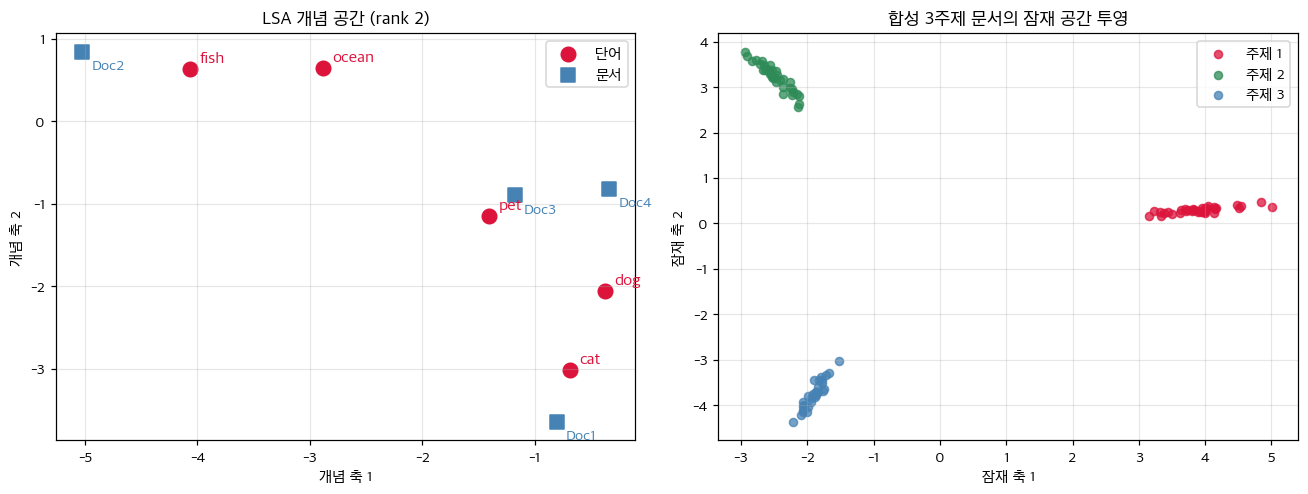

문서-단어 행렬의 특이값 상위 8개: [32.441 29.139 28.031  3.048  2.841  2.722  2.633  2.588]
σ₃ / σ₄ 비율 = 9.20  <- 3개 주제라 4번째부터 뚝 떨어진다

잠재 공간 평균 거리 — 같은 주제: 0.602 / 다른 주제: 7.053
같은 주제끼리 더 가까운가? True


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

# (좌) 작은 LSA 예제의 개념 공간
ax[0].scatter(term_coords[:, 0], term_coords[:, 1], s=90, color="crimson", label="단어")
for t, (x, y) in zip(terms, term_coords):
    ax[0].annotate(t, (x, y), fontsize=11, xytext=(6, 4), textcoords="offset points", color="crimson")
ax[0].scatter(doc_coords[:, 0], doc_coords[:, 1], s=90, marker="s", color="steelblue", label="문서")
for i, (x, y) in enumerate(doc_coords):
    ax[0].annotate(f"Doc{i+1}", (x, y), fontsize=10, xytext=(6, -12), textcoords="offset points", color="steelblue")
ax[0].set_xlabel("개념 축 1"); ax[0].set_ylabel("개념 축 2")
ax[0].set_title("LSA 개념 공간 (rank 2)"); ax[0].legend(); ax[0].grid(alpha=0.3)

# (우) 연습문제 4: 3개 주제 x 100문서 x 50단어
rng4 = np.random.default_rng(3)
n_docs, n_terms, n_topics = 100, 50, 3
doc_topic = rng4.integers(0, n_topics, n_docs)
X_td = 0.15 * rng4.random((n_docs, n_terms))                  # 배경 노이즈
for t in range(n_topics):
    term_ids = np.arange(t * 5, t * 5 + 5)                    # 주제마다 전용 단어 5개
    rows = np.where(doc_topic == t)[0]
    X_td[np.ix_(rows, term_ids)] += rng4.uniform(1.5, 3.0, (len(rows), 5))

S_td = np.linalg.svd(X_td, compute_uv=False)
Ud, Sd, Vtd = np.linalg.svd(X_td - X_td.mean(0), full_matrices=False)
proj = Ud[:, :3] * Sd[:3]                                     # 3D 잠재 공간 좌표

for t, c in zip(range(n_topics), ["crimson", "seagreen", "steelblue"]):
    m = doc_topic == t
    ax[1].scatter(proj[m, 0], proj[m, 1], s=28, alpha=0.75, color=c, label=f"주제 {t+1}")
ax[1].set_xlabel("잠재 축 1"); ax[1].set_ylabel("잠재 축 2")
ax[1].set_title("합성 3주제 문서의 잠재 공간 투영"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("문서-단어 행렬의 특이값 상위 8개:", np.round(S_td[:8], 3))
print(f"σ₃ / σ₄ 비율 = {S_td[2]/S_td[3]:.2f}  <- 3개 주제라 4번째부터 뚝 떨어진다")

# 같은 주제 문서끼리 정말 더 가까운가?
from itertools import combinations
same, diff = [], []
for i, j in combinations(range(n_docs), 2):
    d = np.linalg.norm(proj[i] - proj[j])
    (same if doc_topic[i] == doc_topic[j] else diff).append(d)
print(f"\n잠재 공간 평균 거리 — 같은 주제: {np.mean(same):.3f} / 다른 주제: {np.mean(diff):.3f}")
print("같은 주제끼리 더 가까운가?", np.mean(same) < np.mean(diff))

## 🔟 🏭 실무 5 — 유사역행렬(pseudoinverse)과 최소제곱

### 🧸 비유

방정식이 **미지수보다 많으면** 모두를 동시에 만족시키는 답이 **없다**.
그럴 땐 "전부 다 만족"이 아니라 **"전체적으로 가장 덜 틀린 답"** 을 찾는다. 그게 최소제곱이고, 유사역행렬이 그 답을 바로 준다.

### 📐 개념

**무어-펜로즈 유사역행렬 `A⁺`** 는 역행렬 개념을 **정사각이 아니거나 특이한(singular) 행렬**로 확장한 것이다. SVD가 있으면 계산이 아주 쉽다.

```
A = U Σ Vᵀ  이면

A⁺ = V Σ⁺ Uᵀ

Σ⁺ 만드는 법:
  1. Σ를 전치한다 (행·열 바꾸기)
  2. 0이 아닌 대각 성분 σᵢ 를 1/σᵢ 로 바꾼다
  3. 0은 0으로 그대로 둔다

A 가 (m x n)     ->  A⁺ 는 (n x m)
Σ 가 (m x n)     ->  Σ⁺ 는 (n x m)
```

`Ax = b` 에 **정확한 해가 없을 때**(과결정 시스템), `x = A⁺b` 가 **최소제곱 해**다 (`‖Ax − b‖` 최소화).

```
과결정 시스템 (방정식이 미지수보다 많음):

  [1  1]         [3]
  [2  1] x   =   [5]      정확한 해가 존재하지 않는다.
  [3  1]         [6]

  x_ls = A⁺ b = V Σ⁺ Uᵀ b

  잔차 제곱합을 최소화하는 x를 준다.
  정규방정식 (AᵀA)⁻¹Aᵀb 와 결과는 같지만, 수치적으로 훨씬 안정적이다.
```

In [25]:
# 원문 Step 5 재현
A = np.array([[1, 1], [2, 1], [3, 1]], dtype=float)
b = np.array([3, 5, 6], dtype=float)

U, S, Vt = np.linalg.svd(A, full_matrices=False)
S_inv = np.diag(1.0 / S)
A_pinv = Vt.T @ S_inv @ U.T

x_svd   = A_pinv @ b
x_lstsq = np.linalg.lstsq(A, b, rcond=None)[0]
x_pinv  = np.linalg.pinv(A) @ b
x_norm  = np.linalg.inv(A.T @ A) @ A.T @ b          # 정규방정식(비교용)

print(f"SVD 유사역행렬 해   : {x_svd}")
print(f"np.linalg.lstsq 해  : {x_lstsq}")
print(f"np.linalg.pinv 해   : {x_pinv}")
print(f"정규방정식 해        : {x_norm}")
print(f"\n잔차 ‖Ax-b‖ = {np.linalg.norm(A @ x_svd - b):.6f}  (0이 아님 = 정확한 해가 없다는 증거)")

# 무어-펜로즈 4가지 조건 검증
print("\n무어-펜로즈 조건 검증")
print("  A A⁺ A = A      :", np.allclose(A @ A_pinv @ A, A))
print("  A⁺ A A⁺ = A⁺    :", np.allclose(A_pinv @ A @ A_pinv, A_pinv))
print("  (A A⁺)ᵀ = A A⁺  :", np.allclose((A @ A_pinv).T, A @ A_pinv))
print("  (A⁺ A)ᵀ = A⁺ A  :", np.allclose((A_pinv @ A).T, A_pinv @ A))

SVD 유사역행렬 해   : [1.5    1.6667]
np.linalg.lstsq 해  : [1.5    1.6667]
np.linalg.pinv 해   : [1.5    1.6667]
정규방정식 해        : [1.5    1.6667]

잔차 ‖Ax-b‖ = 0.408248  (0이 아님 = 정확한 해가 없다는 증거)

무어-펜로즈 조건 검증
  A A⁺ A = A      : True
  A⁺ A A⁺ = A⁺    : True
  (A A⁺)ᵀ = A A⁺  : True
  (A⁺ A)ᵀ = A⁺ A  : True


x_ls 주변 1681개 점 중 최소 잔차 : 0.408248  (offset dx=0.00, dy=0.00)
x_ls 자신의 잔차                 : 0.408248  <- 이게 최소


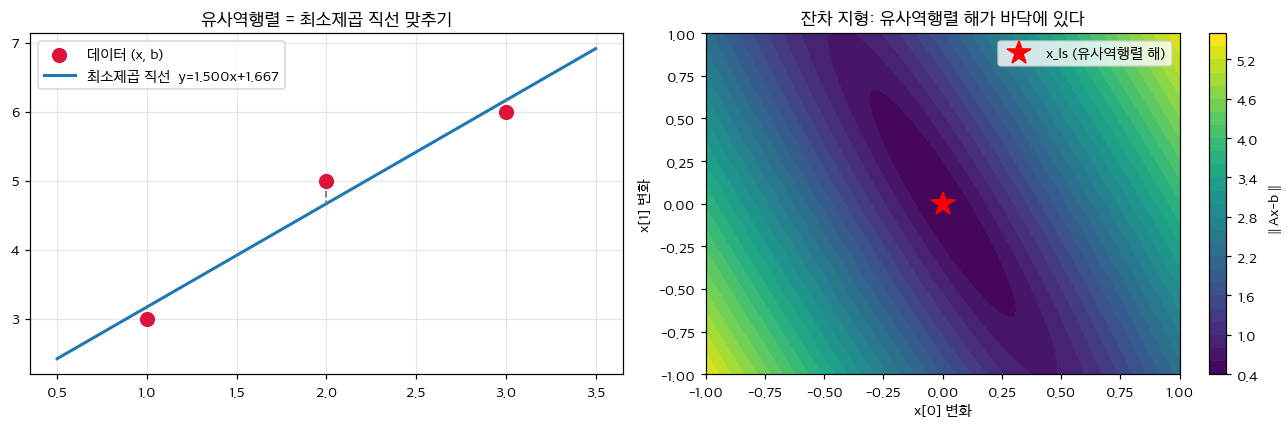

In [26]:
# 정말 '최소'인가? 주변 점들과 비교 + 그림
grid = np.linspace(-1, 1, 41)
best = min(((np.linalg.norm(A @ (x_svd + np.array([dx, dy])) - b), dx, dy)
            for dx in grid for dy in grid), key=lambda t: t[0])
print(f"x_ls 주변 1681개 점 중 최소 잔차 : {best[0]:.6f}  (offset dx={best[1]:.2f}, dy={best[2]:.2f})")
print(f"x_ls 자신의 잔차                 : {np.linalg.norm(A @ x_svd - b):.6f}  <- 이게 최소")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
xs = A[:, 0]
ax[0].scatter(xs, b, s=80, color="crimson", zorder=3, label="데이터 (x, b)")
line = np.linspace(0.5, 3.5, 50)
ax[0].plot(line, x_svd[0] * line + x_svd[1], lw=2, label=f"최소제곱 직선  y={x_svd[0]:.3f}x+{x_svd[1]:.3f}")
for xi, bi in zip(xs, b):
    ax[0].plot([xi, xi], [bi, x_svd[0]*xi + x_svd[1]], color="gray", ls="--", lw=1.2)
ax[0].set_title("유사역행렬 = 최소제곱 직선 맞추기"); ax[0].legend(); ax[0].grid(alpha=0.3)

# 잔차 지형도
DX, DY = np.meshgrid(np.linspace(-1, 1, 120), np.linspace(-1, 1, 120))
Z = np.zeros_like(DX)
for i in range(DX.shape[0]):
    for j in range(DX.shape[1]):
        Z[i, j] = np.linalg.norm(A @ (x_svd + np.array([DX[i, j], DY[i, j]])) - b)
cs = ax[1].contourf(DX, DY, Z, levels=25, cmap="viridis")
ax[1].plot(0, 0, "r*", markersize=16, label="x_ls (유사역행렬 해)")
plt.colorbar(cs, ax=ax[1], label="‖Ax-b‖")
ax[1].set_xlabel("x[0] 변화"); ax[1].set_ylabel("x[1] 변화")
ax[1].set_title("잔차 지형: 유사역행렬 해가 바닥에 있다"); ax[1].legend()
plt.tight_layout(); plt.show()

In [27]:
# 특이(singular)해서 역행렬이 아예 없는 경우에도 유사역행렬은 동작한다
A_sing = np.array([[1., 2.], [2., 4.], [3., 6.]])    # 두 열이 종속 -> rank 1
print("rank(A_sing) =", np.linalg.matrix_rank(A_sing), "(열이 2개인데 rank 1 = 특이)")
try:
    np.linalg.inv(A_sing.T @ A_sing)
except np.linalg.LinAlgError as e:
    print("정규방정식 (AᵀA)⁻¹ :", type(e).__name__, "-", e, "  <- 실패")

U, S, Vt = np.linalg.svd(A_sing, full_matrices=False)
print("특이값:", np.round(S, 6), " <- 두 번째가 0")
tol = 1e-10
S_plus = np.array([1/s if s > tol else 0.0 for s in S])     # 0은 0으로 남긴다 (핵심!)
A_sing_pinv = Vt.T @ np.diag(S_plus) @ U.T
b2 = np.array([1., 2., 4.])
print("\n유사역행렬 해     :", A_sing_pinv @ b2)
print("np.linalg.pinv 해 :", np.linalg.pinv(A_sing) @ b2, " <- 동일. 최소노름 최소제곱 해")

rank(A_sing) = 1 (열이 2개인데 rank 1 = 특이)
정규방정식 (AᵀA)⁻¹ : LinAlgError - Singular matrix   <- 실패
특이값: [8.3666 0.    ]  <- 두 번째가 0

유사역행렬 해     : [0.2429 0.4857]
np.linalg.pinv 해 : [0.2429 0.4857]  <- 동일. 최소노름 최소제곱 해


## 1️⃣1️⃣ 🏭 실무 6 — PCA는 사실 SVD다

### 📐 개념

### 🧭 예전에 배운 대각화와 PCA는 어떻게 이어지나?

예전에 배운 내용은 아마 이런 형태였을 것이다.

```
A = P Λ P⁻¹
```

여기서 `P`는 고유벡터들을 모은 행렬이고, `Λ`는 고유값들을 대각선에 둔 대각 행렬이다.

이 식은 이렇게 읽을 수 있다.

```
P⁻¹ : 고유벡터 좌표계로 이동
Λ   : 각 고유벡터 축을 λ만큼 늘리거나 줄임
P   : 원래 좌표계로 돌아옴
```

즉, 복잡한 행렬을 좋은 좌표계에서 보면 **축별 스케일 조절**처럼 단순하게 볼 수 있다는 뜻이다.

PCA도 같은 감각을 데이터에 적용한다. 다만 PCA가 직접 대각화하는 행렬은 원래 데이터 `X`가 아니라, 데이터가 어떤 방향으로 얼마나 퍼져 있는지를 담은 **공분산 행렬**이다.

```
C = (1/(n-1)) XᵀX
C = V Λ Vᵀ
```

여기서 `V`는 PCA의 주성분 방향이고, `Λ`의 고유값은 각 방향으로 데이터가 얼마나 크게 퍼져 있는지, 즉 **설명분산**이다.

SVD와 모양도 거의 같다.

```
고유분해: A = P Λ P⁻¹
SVD     : X = U Σ Vᵀ
PCA     : C = V Λ Vᵀ
```

그래서 PCA가 SVD와 비슷하게 느껴지는 것은 맞다. PCA는 **공분산 행렬을 대각화해서 데이터가 가장 많이 퍼진 축을 찾는 방법**이고, 실제 계산은 중심화된 데이터 `X`의 SVD로 바로 할 수 있다.

### 📊 공분산 행렬은 무엇인가?

공분산 행렬은 **특징들이 서로 같이 움직이는 정도**를 표로 만든 것이다.

예를 들어 데이터의 특징이 `height`, `weight`, `age`라면 공분산 행렬은 이런 질문에 답한다.

```
height가 커질 때 weight도 같이 커지는가?
height가 커질 때 age도 같이 커지는가?
weight와 age는 같이 움직이는가?
```

모양은 대략 이렇게 생겼다.

```
          height   weight   age
height     var      cov     cov
weight     cov      var     cov
age        cov      cov     var
```

대각선의 `var`는 각 특징 자체의 분산이다. 즉, 그 특징이 얼마나 넓게 퍼져 있는지다.

대각선 밖의 `cov`는 두 특징이 같이 움직이는 정도다.

```
cov > 0  : 둘이 대체로 같은 방향으로 움직임
cov < 0  : 하나가 커질 때 다른 하나는 작아지는 경향
cov ≈ 0  : 선형적으로 같이 움직이는 경향이 약함
```

PCA는 이 공분산 행렬을 보고 이렇게 묻는다.

```
데이터가 가장 크게 퍼져 있는 방향은 어디인가?
그 다음으로 크게 퍼져 있는 방향은 어디인가?
```

그 방향들이 PCA의 주성분이고, 그 방향을 고유벡터로 찾는다.

**PCA = 중심화한 데이터에 대한 SVD.** 비유가 아니라 **문자 그대로 같은 계산**이다.

```
데이터 행렬 X (n_samples x n_features), 평균을 뺀 상태:

공분산 행렬: C = (1/(n-1)) XᵀX

PCA는 C의 고유벡터를 찾는다. 그런데:

  X = U Σ Vᵀ           (X의 SVD)

  XᵀX = V Σ² Vᵀ

  C = (1/(n-1)) V Σ² Vᵀ

따라서 주성분은 정확히 오른쪽 특이벡터 V 이다.
각 성분의 설명 분산은 σᵢ² / (n-1) 이다.

sklearn의 PCA는 고유분해가 아니라 SVD로 구현되어 있다.
더 빠르고 수치적으로 더 안정적이기 때문이다.
```

> 즉, **3주차(Lesson 10)에서 배운 차원 축소는 전부 내부적으로 SVD였다.**
> PCA는 머신러닝에서 SVD가 가장 흔하게 쓰이는 응용이다.

In [28]:
# 3주차 노트북의 PCA를 그대로 가져와 SVD와 같은 결과가 나오는지 확인
rng5 = np.random.default_rng(0)
n, d = 500, 6
latent = rng5.standard_normal((n, 3)) * np.array([5., 3., 1.])
X = np.hstack([latent, latent @ rng5.standard_normal((3, 3))]) + 0.4 * rng5.standard_normal((n, d))

Xc = X - X.mean(0)

# 경로 A: 공분산 행렬의 고유분해 (3주차 방식)
cov = np.cov(Xc, rowvar=False)
evals, evecs = np.linalg.eigh(cov)
order = np.argsort(evals)[::-1]
evals, evecs = evals[order], evecs[:, order]

# 경로 B: 중심화 데이터의 SVD
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
explained_var_svd = S**2 / (n - 1)

print("공분산 고유값 (설명분산):", np.round(evals, 5))
print("σ²/(n-1)         :", np.round(explained_var_svd, 5))
print("일치:", np.allclose(evals, explained_var_svd))

print("\n주성분 방향 일치 여부 (|내적|, 1이면 같은 방향)")
print(np.round(np.abs(np.sum(evecs * Vt.T, axis=0)), 8))

print("\n설명분산비 (상위 3개):", np.round(explained_var_svd[:3] / explained_var_svd.sum(), 4))
print("누적:", f"{explained_var_svd[:3].sum()/explained_var_svd.sum():.4f}")

# 투영 결과까지 같은지
proj_eig = Xc @ evecs[:, :2]
proj_svd = U[:, :2] * S[:2]          # = Xc @ V[:, :2]
print("\n투영 좌표 일치(부호 제외):", np.allclose(np.abs(proj_eig), np.abs(proj_svd)))

공분산 고유값 (설명분산): [110.6007  20.7854   2.1653   0.1705   0.1625   0.1548]
σ²/(n-1)         : [110.6007  20.7854   2.1653   0.1705   0.1625   0.1548]
일치: True

주성분 방향 일치 여부 (|내적|, 1이면 같은 방향)
[1. 1. 1. 1. 1. 1.]

설명분산비 (상위 3개): [0.8251 0.1551 0.0162]
누적: 0.9964

투영 좌표 일치(부호 제외): True


## 1️⃣2️⃣ 🔨 Build It — 밑바닥부터 SVD 구현하기 (Power Iteration)

### 🧸 비유

여러 사람이 **밧줄을 아무 방향으로나 잡고** 있다. 여기서 **가장 힘센 사람의 방향**을 찾고 싶다.
방법: 모두 한 번 잡아당기고, 결과 방향을 다시 잡아당기고, 또 당기고… **반복할수록 가장 힘센 방향으로 수렴**한다. 이게 **거듭제곱 반복(power iteration)** 이다.

가장 힘센 방향을 찾았으면, 그 방향의 기여분을 **빼내고(deflation)** 같은 걸 반복 → 두 번째, 세 번째 특이값이 나온다.

### 📐 개념 — 알고리즘

1. `AᵀA`에 power iteration을 돌려 **가장 큰 고유값 λ₁과 고유벡터 v₁** 을 얻는다.
2. `σ₁ = √λ₁`, `u₁ = A v₁ / σ₁`.
3. `A ← A − σ₁ u₁ v₁ᵀ` (지금 찾은 rank-1 성분을 빼낸다 = **deflation**).
4. 1~3을 `k`번 반복.

In [29]:
def power_iteration(M, num_iters=100):
    n = M.shape[1]
    v = np.random.randn(n)
    v = v / np.linalg.norm(v)

    for _ in range(num_iters):
        Mv = M @ v
        v = Mv / np.linalg.norm(Mv)

    eigenvalue = v @ M @ v          # 레일리 몫 (v가 단위벡터이므로)
    return eigenvalue, v


def svd_from_scratch(A, k=None):
    m, n = A.shape
    if k is None:
        k = min(m, n)

    sigmas, us, vs = [], [], []
    A_residual = A.copy().astype(float)

    for _ in range(k):
        AtA = A_residual.T @ A_residual
        eigenvalue, v = power_iteration(AtA, num_iters=200)

        if eigenvalue < 1e-10:      # 남은 게 없으면 중단
            break

        sigma = np.sqrt(eigenvalue)
        u = A_residual @ v / sigma

        sigmas.append(sigma)
        us.append(u)
        vs.append(v)

        A_residual = A_residual - sigma * np.outer(u, v)     # deflation

    U = np.column_stack(us) if us else np.empty((m, 0))
    S = np.array(sigmas)
    V = np.column_stack(vs) if vs else np.empty((n, 0))
    return U, S, V

print("정의 완료 — power_iteration, svd_from_scratch")

정의 완료 — power_iteration, svd_from_scratch


### Step 2 — NumPy와 비교

In [30]:
np.random.seed(42)
A = np.random.randn(5, 4)

U_ours, S_ours, V_ours = svd_from_scratch(A)
U_np, S_np, Vt_np = np.linalg.svd(A, full_matrices=False)

print("우리 구현의 특이값 :", np.round(S_ours, 4))
print("NumPy의 특이값     :", np.round(S_np, 4))
print("최대 차이          :", np.abs(np.sort(S_ours)[::-1] - S_np).max())

A_reconstructed = U_ours @ np.diag(S_ours) @ V_ours.T
print(f"\n복원 오차: {np.linalg.norm(A - A_reconstructed):.8f}")

print("\n직교성 검증 (우리 구현)")
print("  ‖UᵀU - I‖ =", np.linalg.norm(U_ours.T @ U_ours - np.eye(U_ours.shape[1])))
print("  ‖VᵀV - I‖ =", np.linalg.norm(V_ours.T @ V_ours - np.eye(V_ours.shape[1])))

print("\n핵심 등식 A vᵢ = σᵢ uᵢ 도 성립하는가:")
for i in range(len(S_ours)):
    err = np.linalg.norm(A @ V_ours[:, i] - S_ours[i] * U_ours[:, i])
    print(f"  i={i}  오차 = {err:.2e}")

우리 구현의 특이값 : [3.4038 2.2974 1.0119 0.4588]
NumPy의 특이값     : [3.4038 2.2974 1.0119 0.4588]
최대 차이          : 1.3322676295501878e-15

복원 오차: 0.00000000

직교성 검증 (우리 구현)
  ‖UᵀU - I‖ = 7.031877061288514e-16
  ‖VᵀV - I‖ = 4.235280193203289e-16

핵심 등식 A vᵢ = σᵢ uᵢ 도 성립하는가:
  i=0  오차 = 2.22e-16
  i=1  오차 = 1.57e-16
  i=2  오차 = 3.70e-16
  i=3  오차 = 4.74e-16


### 🖼️ 그림 7 — power iteration이 수렴하는 과정

반복 횟수를 늘릴수록 추정한 σ₁이 참값에 **기하급수적으로** 가까워진다.
수렴 속도는 `(σ₂/σ₁)²` 비율에 달려 있다 — **1등과 2등의 격차가 클수록 빨리 수렴한다.**

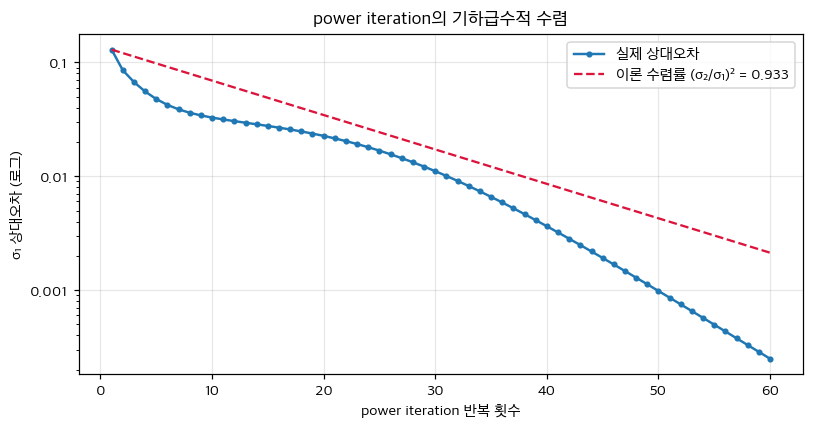

참 σ₁ = 9.952878,  σ₂ = 9.612547,  비율 (σ₂/σ₁)² = 0.9328
반복 10회 오차: 3.27e-02 / 30회: 1.11e-02 / 60회: 2.50e-04


In [32]:
np.random.seed(0)
A_t = np.random.randn(40, 25)
sigma1_true = np.linalg.svd(A_t, compute_uv=False)[0]
AtA_t = A_t.T @ A_t

errs_pi, iters = [], range(1, 61)
for it in iters:
    np.random.seed(1)
    lam, _ = power_iteration(AtA_t, num_iters=it)
    errs_pi.append(abs(np.sqrt(max(lam, 0)) - sigma1_true) / sigma1_true)

sv = np.linalg.svd(A_t, compute_uv=False)
rate = (sv[1] / sv[0]) ** 2

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.semilogy(iters, np.maximum(errs_pi, 1e-17), "o-", ms=3, lw=1.6, label="실제 상대오차")
ax.semilogy(iters, np.maximum(errs_pi[0] * rate ** np.arange(len(iters)), 1e-17),
            "--", color="crimson", label=f"이론 수렴률 (σ₂/σ₁)² = {rate:.3f}")
plain_log(ax)
ax.set_xlabel("power iteration 반복 횟수"); ax.set_ylabel("σ₁ 상대오차 (로그)")
ax.set_title("power iteration의 기하급수적 수렴"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"참 σ₁ = {sigma1_true:.6f},  σ₂ = {sv[1]:.6f},  비율 (σ₂/σ₁)² = {rate:.4f}")
print(f"반복 10회 오차: {errs_pi[9]:.2e} / 30회: {errs_pi[29]:.2e} / 60회: {errs_pi[59]:.2e}")

## 1️⃣3️⃣ 📝 연습문제

원문의 5문제. **2·3·4번은 위에서 이미 다뤘고**, 여기서는 **1번과 5번**을 마저 푼다.

1. **(여기서 품)** power iteration 없이 SVD 구현하기. `AᵀA`의 고유분해로 `V`와 특이값을 얻고, `U = A V Σ⁻¹`로 `U`를 구한다. power iteration 버전 및 NumPy와 **수치 정확도를 비교**하라.
2. ✅ *(6️⃣에서 완료)* 실제 흑백 이미지를 rank 1, 5, 10, 25, 50, 100으로 압축하고 압축률·상대오차를 구한 뒤 **눈으로 봐줄 만한 rank**를 찾아라.
3. ✅ *(8️⃣에서 완료)* 10×8 사용자-영화 평점 행렬로 미니 추천 시스템을 만들어라. 결측은 행 평균으로 채우고 rank-3 근사로 예측한 뒤 **예측이 합리적인지** 확인하라.
4. ✅ *(9️⃣에서 완료)* 3개 주제(주제당 단어 5개)를 가진 100×50 문서-단어 행렬을 만들고 노이즈를 더한 뒤, **상위 3개 특이값이 압도적으로 큰지**와 **같은 주제 문서가 뭉치는지** 확인하라.
5. **(여기서 품)** rank 3짜리 깨끗한 50×40 행렬에 여러 세기(σ = 0.1, 0.5, 1.0, 2.0)의 가우시안 노이즈를 더하라. 각 노이즈 수준에서 `k`를 1~40까지 훑어 **깨끗한 행렬 대비 오차를 최소화하는 최적 k**를 찾고, **노이즈 세기에 따라 최적 k가 어떻게 변하는지** 그려라.

### 연습문제 1 — 고유분해 기반 SVD vs power iteration vs NumPy

In [28]:
def svd_via_eigen(A):
    A = A.astype(float)
    evals, evecs = np.linalg.eigh(A.T @ A)          # AᵀA 는 대칭
    order = np.argsort(evals)[::-1]
    evals, evecs = evals[order], evecs[:, order]

    sigmas = np.sqrt(np.clip(evals, 0, None))
    keep = sigmas > 1e-12
    sigmas, V = sigmas[keep], evecs[:, keep]
    U = A @ V / sigmas                               # U = A V Σ⁻¹
    return U, sigmas, V


def report(name, U, S, V, A, S_ref):
    rec = np.linalg.norm(A - U @ np.diag(S) @ V.T)
    orth_u = np.linalg.norm(U.T @ U - np.eye(U.shape[1]))
    orth_v = np.linalg.norm(V.T @ V - np.eye(V.shape[1]))
    sig_err = np.abs(np.sort(S)[::-1][:len(S_ref)] - S_ref[:len(S)]).max()
    print(f"{name:<26} σ오차={sig_err:.3e}  복원={rec:.3e}  UᵀU={orth_u:.3e}  VᵀV={orth_v:.3e}")


for label, A_test in [("잘 조건화된 6x4", np.random.default_rng(0).standard_normal((6, 4))),
                      ("악조건 (조건수 1e6)", A_ill)]:
    S_ref = np.linalg.svd(A_test, compute_uv=False)
    print(f"\n[{label}]  참 σ = {np.round(S_ref, 6)}")
    Ue_, Se_, Ve_ = svd_via_eigen(A_test)
    report("고유분해 기반", Ue_, Se_, Ve_, A_test, S_ref)
    np.random.seed(0)
    Up_, Sp_, Vp_ = svd_from_scratch(A_test)
    report("power iteration 기반", Up_, Sp_, Vp_, A_test, S_ref)
    Un_, Sn_, Vtn_ = np.linalg.svd(A_test, full_matrices=False)
    report("NumPy (LAPACK)", Un_, Sn_, Vtn_.T, A_test, S_ref)

print("\n[읽는 법]")
print(" - 잘 조건화된 행렬: 세 방법 모두 기계정밀도(~1e-15) 수준으로 동일하다.")
print(" - 악조건 행렬: 고유분해 기반이 눈에 띄게 무너진다.")
print("     · σ 오차가 1e-9 수준 (기계정밀도보다 6자리 이상 나쁨)")
print("     · U = A V Σ⁻¹ 로 만든 U의 직교성 ‖UᵀU-I‖ 이 1e-5 수준까지 나빠짐")
print("       (작은 σ로 나누는 과정에서 오차가 증폭되기 때문)")
print(" - power iteration도 AᵀA를 만들지만, 잔차에서 매번 새로 만들고 σ가 큰 성분부터")
print("   빼내므로 이 예제에선 버텼다. 보장된 성질이 아니라 운에 가깝다.")
print(" - NumPy(LAPACK)는 AᵀA를 아예 만들지 않는다(Golub-Kahan). 그래서 항상 안전하다.")


[잘 조건화된 6x4]  참 σ = [3.0361 2.0335 1.8563 0.8954]
고유분해 기반                    σ오차=6.661e-16  복원=2.986e-15  UᵀU=8.624e-16  VᵀV=1.559e-15
power iteration 기반         σ오차=4.441e-16  복원=1.178e-15  UᵀU=5.241e-16  VᵀV=4.573e-16
NumPy (LAPACK)             σ오차=1.332e-15  복원=9.795e-15  UᵀU=1.388e-15  VᵀV=1.468e-15

[악조건 (조건수 1e6)]  참 σ = [1000.       1.       0.001]
고유분해 기반                    σ오차=6.520e-09  복원=1.096e-13  UᵀU=1.304e-05  VᵀV=3.663e-16
power iteration 기반         σ오차=1.137e-13  복원=1.138e-13  UᵀU=6.490e-12  VᵀV=1.849e-11
NumPy (LAPACK)             σ오차=6.661e-16  복원=2.466e-13  UᵀU=5.448e-16  VᵀV=9.021e-16

[읽는 법]
 - 잘 조건화된 행렬: 세 방법 모두 기계정밀도(~1e-15) 수준으로 동일하다.
 - 악조건 행렬: 고유분해 기반이 눈에 띄게 무너진다.
     · σ 오차가 1e-9 수준 (기계정밀도보다 6자리 이상 나쁨)
     · U = A V Σ⁻¹ 로 만든 U의 직교성 ‖UᵀU-I‖ 이 1e-5 수준까지 나빠짐
       (작은 σ로 나누는 과정에서 오차가 증폭되기 때문)
 - power iteration도 AᵀA를 만들지만, 잔차에서 매번 새로 만들고 σ가 큰 성분부터
   빼내므로 이 예제에선 버텼다. 보장된 성질이 아니라 운에 가깝다.
 - NumPy(LAPACK)는 AᵀA를 아예 만들지 않는다(Golub-Kahan). 그래서 항상 안전하다.


### 연습문제 5 — 노이즈 세기에 따른 최적 rank

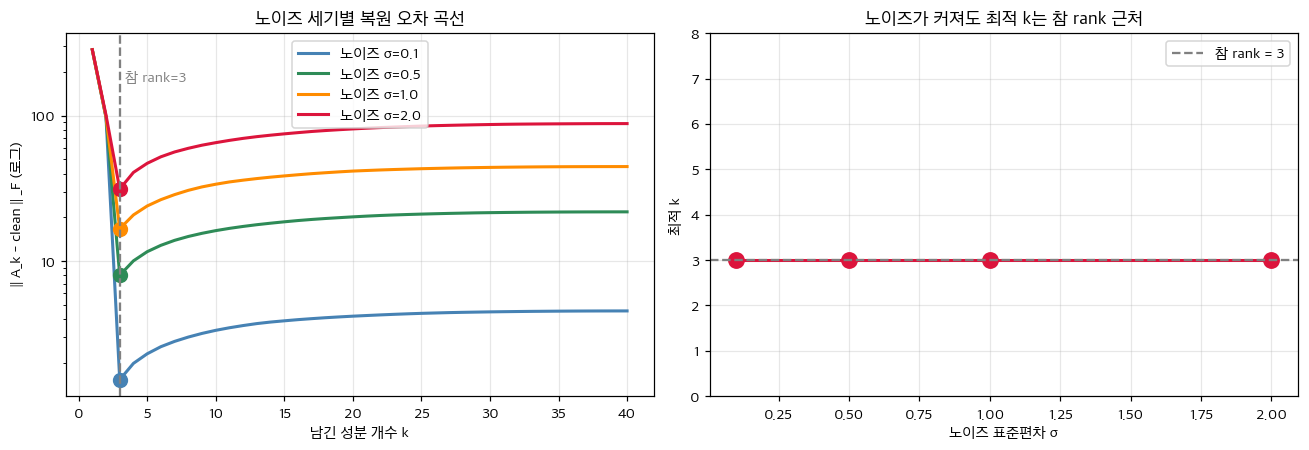

    노이즈 σ |   최적 k |      최소 오차 |     k=40(=원본유지) 오차
      0.1 |      3 |      1.526 |              4.537
      0.5 |      3 |      7.982 |             21.799
      1.0 |      3 |     16.682 |             44.663
      2.0 |      3 |     31.292 |             88.233

해석: 노이즈가 커질수록 곡선 바닥이 얕아지고 오른쪽 상승이 가팔라진다.
      최적 k는 참 rank(3) 근처에 머문다 — SVD가 신호의 진짜 차원을 짚어낸다는 뜻.


In [29]:
rng6 = np.random.default_rng(2024)
r_true = 3
clean50 = (rng6.standard_normal((50, r_true)) * np.array([10., 6., 3.])) @ rng6.standard_normal((r_true, 40))

noise_levels = [0.1, 0.5, 1.0, 2.0]
curves, opt_ks = {}, {}
for s in noise_levels:
    noisy_m = clean50 + s * rng6.standard_normal((50, 40))
    e = [np.linalg.norm(truncate(noisy_m, k) - clean50) for k in range(1, 41)]
    curves[s] = e
    opt_ks[s] = int(np.argmin(e)) + 1

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for s, c in zip(noise_levels, ["steelblue", "seagreen", "darkorange", "crimson"]):
    ax[0].semilogy(range(1, 41), curves[s], lw=2, color=c, label=f"노이즈 σ={s}")
    ax[0].plot(opt_ks[s], curves[s][opt_ks[s] - 1], "o", color=c, ms=9)
ax[0].axvline(r_true, ls="--", color="gray"); ax[0].text(r_true + 0.4, max(curves[2.0])*0.6, "참 rank=3", color="gray")
plain_log(ax[0])
ax[0].set_xlabel("남긴 성분 개수 k"); ax[0].set_ylabel("‖A_k - clean‖_F (로그)")
ax[0].set_title("노이즈 세기별 복원 오차 곡선"); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(noise_levels, [opt_ks[s] for s in noise_levels], "o-", lw=2, ms=10, color="crimson")
ax[1].axhline(r_true, ls="--", color="gray", label="참 rank = 3")
ax[1].set_xlabel("노이즈 표준편차 σ"); ax[1].set_ylabel("최적 k")
ax[1].set_ylim(0, 8); ax[1].set_title("노이즈가 커져도 최적 k는 참 rank 근처"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'노이즈 σ':>9} | {'최적 k':>6} | {'최소 오차':>10} | {'k=40(=원본유지) 오차':>18}")
for s in noise_levels:
    print(f"{s:>9} | {opt_ks[s]:>6} | {min(curves[s]):>10.3f} | {curves[s][39]:>18.3f}")
print("\n해석: 노이즈가 커질수록 곡선 바닥이 얕아지고 오른쪽 상승이 가팔라진다.")
print("      최적 k는 참 rank(3) 근처에 머문다 — SVD가 신호의 진짜 차원을 짚어낸다는 뜻.")

## 1️⃣4️⃣ 📚 용어 사전 (Key Terms)

| 용어 | 사람들이 말하는 것 | 실제 의미 |
| --- | --- | --- |
| **SVD** | "아무 행렬이나 분해" | `A`를 `U Σ Vᵀ`로 분해. `U`, `V`는 직교, `Σ`는 음이 아닌 대각. **어떤 모양의 어떤 행렬이든** 가능. |
| **특이값 (Singular value)** | "이 성분이 얼마나 중요한가" | `Σ`의 `i`번째 대각 성분. `i`번째 주방향으로 행렬이 얼마나 늘리는지. 항상 음이 아니고 내림차순 정렬. |
| **왼쪽 특이벡터** | "출력 방향" | `U`의 열. `i`번째 오른쪽 특이벡터가 (`σᵢ`배 된 뒤) 도착하는 출력 공간의 방향. |
| **오른쪽 특이벡터** | "입력 방향" | `V`의 열. 행렬이 (`σᵢ`배 하여) `i`번째 왼쪽 특이벡터로 보내는 입력 공간의 방향. |
| **잘린 SVD (Truncated SVD)** | "저계수 근사" | 상위 `k`개 특이값·벡터만 남김. **증명 가능하게 최선인** rank-k 근사 (Eckart–Young 정리). |
| **rank (계수)** | "진짜 차원 수" | 0이 아닌 특이값의 개수. 행렬이 실제로 쓰는 독립적 방향의 수. |
| **유사역행렬 (Pseudoinverse)** | "일반화된 역행렬" | `V Σ⁺ Uᵀ`. 0이 아닌 특이값만 역수를 취하고 0은 0으로 둔다. 정사각이 아니거나 특이한 행렬의 최소제곱을 푼다. |
| **조건수 (Condition number)** | "오차에 얼마나 민감한가" | `σ_max / σ_min`. 크면 입력의 작은 변화가 출력의 큰 변화를 낳는다. SVD가 이걸 바로 보여 준다. |
| **잠재 요인 (Latent factor)** | "숨은 변수" | SVD가 찾아낸 저차원 공간의 한 축. 추천에서는 장르 선호, NLP에서는 토픽에 대응할 수 있다. |
| **프로베니우스 노름** | "행렬의 전체 크기" | 모든 원소 제곱합의 제곱근. **특이값 제곱합의 제곱근과 같다.** 근사 오차 측정에 쓴다. |
| **Eckart–Young 정리** | "SVD가 최고의 압축을 준다" | 어떤 목표 rank `k`에 대해서도, 잘린 SVD가 가능한 모든 rank-k 행렬 중 근사 오차를 최소화한다. |
| **Power iteration** | "가장 큰 고유벡터 찾기" | 무작위 벡터에 행렬을 반복해서 곱하고 정규화. 가장 큰 고유값의 고유벡터로 수렴. 많은 SVD 알고리즘의 기본 블록. |

In [30]:
# 용어들을 한 번에 확인하는 요약 코드
A = rng.standard_normal((8, 5))
U, S, Vt = np.linalg.svd(A, full_matrices=False)

print(f"rank            = {np.sum(S > 1e-10)}  (0이 아닌 특이값 개수)")
print(f"조건수          = {S[0]/S[-1]:.4f}  == np.linalg.cond: {np.linalg.cond(A):.4f}")
print(f"프로베니우스노름 = {np.linalg.norm(A):.6f}  == √Σσᵢ²: {np.sqrt(np.sum(S**2)):.6f}")
print(f"스펙트럼 노름    = {np.linalg.norm(A, 2):.6f}  == σ₁: {S[0]:.6f}")
print(f"핵 노름(nuclear) = {np.linalg.norm(A, 'nuc'):.6f}  == Σσᵢ: {np.sum(S):.6f}")
print(f"|det| (정사각 아님이라 생략), 유사역행렬 rank = {np.linalg.matrix_rank(np.linalg.pinv(A))}")

rank            = 5  (0이 아닌 특이값 개수)
조건수          = 5.6138  == np.linalg.cond: 5.6138
프로베니우스노름 = 5.960756  == √Σσᵢ²: 5.960756
스펙트럼 노름    = 4.525949  == σ₁: 4.525949
핵 노름(nuclear) = 11.617039  == Σσᵢ: 11.617039
|det| (정사각 아님이라 생략), 유사역행렬 rank = 5


## 🚢 Use It / Ship It

원문에서 안내하는 실행 자산:

```bash
# 전체 데모 (이미지 압축, 추천 시스템, LSA, 노이즈 제거)
python svd.py        # code/svd.py

# Julia 버전 — Julia 기본 svd() 와 LinearAlgebra 패키지 사용
julia svd.jl         # code/svd.jl
```

**Ship It — 이 레슨의 산출물**

- `outputs/skill-svd.md` — *실제 프로젝트에서 SVD를 **언제, 어떻게** 적용할지 판단하는 스킬 문서*

**언제 SVD를 꺼낼지 판단표 (스터디용 정리)**

| 상황 | SVD로 하는 일 | 실무 팁 |
| --- | --- | --- |
| 행렬이 너무 커서 저장/연산이 부담 | 잘린 SVD로 저계수 압축 | 특이값 감소가 느리면 포기 (압축 안 됨) |
| 측정 데이터에 노이즈가 낌 | 특이값 계단 위쪽만 남겨 복원 | 계단이 안 보이면 신호/노이즈 분리 곤란 |
| 결측이 많은 평점·상호작용 행렬 | 잠재 요인 분해로 빈칸 예측 | 실무는 ALS/Funk SVD (결측 직접 처리) |
| 텍스트에서 의미 유사도 | LSA (단어-문서 행렬 SVD) | TF-IDF 가중 후 적용하는 게 보통 |
| `Ax=b`에 해가 없음 / 특이행렬 | 유사역행렬로 최소제곱 | `pinv`/`lstsq` 사용, 정규방정식 금지 |
| 특징이 너무 많음 | PCA (= 중심화 후 SVD) | `sklearn.PCA`가 이미 SVD 기반 |
| 수치가 불안정한 것 같음 | 조건수 `σ_max/σ_min` 확인 | `np.linalg.cond`로 즉시 진단 |

## 📖 더 읽을거리 (Further Reading)

- [Gilbert Strang, *Linear Algebra and Its Applications*, Ch. 7](https://math.mit.edu/~gs/linearalgebra/) — SVD와 응용의 정석
- [3Blue1Brown: But what is the SVD?](https://www.youtube.com/watch?v=vSczTbgc8Rc) — 기하학적 직관
- [We Recommend a Singular Value Decomposition (AMS)](https://www.ams.org/publicoutreach/feature-column/fcarc-svd) — 쉬운 개괄
- [Netflix Prize and Matrix Factorization (Simon Funk)](https://sifter.org/~simon/journal/20061211.html) — 추천 SVD 원조 글
- [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis) — NLP 최초 응용
- [Trefethen & Bau, *Numerical Linear Algebra*](https://people.maths.ox.ac.uk/trefethen/text.html) — SVD 알고리즘과 수치적 성질의 표준서

---

## 🎯 한 문장 정리

> **SVD = "모든 행렬은 돌리고(Vᵀ) · 늘리고(Σ) · 돌린다(U)"를 낱낱이 적어 준 설명서.**
> 늘린 배율 σ가 큰 순서대로 정렬돼 있어서, **뒤에서부터 잘라내면 그게 곧 최선의 압축**이다 (Eckart–Young).

| 개념 | 한 줄 요약 |
| --- | --- |
| `A = UΣVᵀ` | 회전 → 크기조절 → 회전. 모든 행렬에 항상 존재 |
| `A vᵢ = σᵢ uᵢ` | 입력 방향 `vᵢ`를 `σᵢ`배 해서 출력 방향 `uᵢ`로 보낸다 |
| 외적 합 | `A = Σ σᵢ uᵢ vᵢᵀ` — 중요한 레이어부터 쌓기 |
| 잘린 SVD | 상위 k개만 남기면 **rank-k 최적 근사** |
| 압축 | 특이값이 빨리 줄면 압축 성공, 느리면 실패 |
| 노이즈 제거 | 특이값 계단 위쪽=신호, 아래쪽=노이즈 |
| 유사역행렬 | `A⁺ = VΣ⁺Uᵀ` — 해 없는 방정식의 최소제곱 해 |
| PCA | 중심화 데이터의 SVD와 **문자 그대로 동일** |
| 수치 안정성 | `AᵀA`를 만들면 조건수가 제곱된다 → 직접 SVD |